# Student Performance Analysis & Early-Warning Prediction
### Professional Applied Machine Learning Project — Educational Data Mining

**Primary application:** Mid-semester Pass/Fail early-warning classification
**Secondary application:** Final score regression (same feature set, for comparison/interpretability)

**Dataset:** `student_data_cleaned.xlsx` — 20,000 students × 41 variables

This notebook follows a full professional ML workflow: data audit → leakage audit → EDA →
feature engineering → preprocessing pipeline → baseline → advanced models → cross-validation
& hyperparameter tuning → evaluation → error analysis → explainable AI (SHAP) →
robustness/fairness → final model selection → conclusion.

> Designed to run as a **Kaggle Notebook** with the dataset attached as a Kaggle Input dataset.


## Section A — Environment & Libraries

In [56]:
!pip install lightgbm shap

In [57]:
# Core
import os
import sys
import warnings
import random

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
from scipy import stats

# Modeling
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, matthews_corrcoef, log_loss, brier_score_loss,
    balanced_accuracy_score, RocCurveDisplay, PrecisionRecallDisplay,
    mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
)

warnings.filterwarnings("ignore")

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

print("Environment ready. Random seed fixed at", RANDOM_STATE)


Environment ready. Random seed fixed at 42


In [58]:
# Optional advanced libraries (install if not already present — Kaggle usually has these preinstalled)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not found — will fall back to LightGBM/RandomForest only")

try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("lightgbm not found — will fall back to XGBoost/RandomForest only")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not found — install with `pip install shap` for the explainability section")

print("xgboost available:", HAS_XGB)
print("lightgbm available:", HAS_LGBM)
print("shap available:", HAS_SHAP)

assert HAS_XGB or HAS_LGBM, "Need at least one of xgboost/lightgbm installed for the advanced boosting model."


xgboost available: True
lightgbm available: True
shap available: True


## Section B — Data Loading

This cell is written to work directly inside a **Kaggle Notebook**. It searches
`/kaggle/input/` recursively for `student_data_cleaned.xlsx` (Kaggle mounts attached
datasets under `/kaggle/input/<dataset-slug>/...`, and the exact slug can vary), so you
don't need to hard-code the dataset slug. If it's not found (e.g. running locally), it
falls back to a local path you can edit.


In [59]:
df_raw = pd.read_excel("/kaggle/input/datasets/ahmedgamal202200133/student-data-cleaned-cleaned/student_data_cleaned.xlsx")
print("\nShape:", df_raw.shape)
df_raw.head(10)



Shape: (20000, 41)


,age,gender,parent_income,num_siblings,family_support,commute_time_min,part_time_job,previous_gpa,num_failed_courses,high_school_grade,math_background_score,language_background_score,science_background_score,prior_semester_credits,study_hours_last_semester,past_attendance_rate,academic_warnings_count,lecture_attendance_rate,assignment_submission_rate,quiz_avg_score,midterm_score,lab_participation_rate,online_portal_usage_minutes,group_project_activity,library_visits_per_month,discussion_forum_posts,lateness_count,stress_level,sleep_hours,motivation_level,study_time_per_week,concentration_level,exam_anxiety_level,course_difficulty_rating,teacher_experience_years,class_size,num_prerequisites,course_type,final_score,final_grade,pass_fail
0,24,Female,22678,0,1,95,No,2.2200,3,99.7000,34,91,32,20,140,86,3,60,67,98,49,89,1003,61,8,27,9,8,3.3000,2,6,7,6,2,11,95,3,Elective,66.5000,C,Pass
1,21,Male,17905,3,2,0,Yes,3.7800,1,75.7000,91,21,87,14,32,84,1,74,74,5,93,32,692,35,16,32,10,1,6.8000,2,2,3,3,1,20,148,2,Elective,81.7000,B,Pass
2,28,Male,16005,0,0,67,No,2.5000,4,93.4000,32,30,13,15,180,72,3,96,77,53,74,82,1918,60,17,18,11,7,6.4000,1,13,1,8,1,32,55,3,Elective,77.3000,B,Pass
3,25,Female,29391,4,4,83,Yes,1.8400,4,69.7000,33,19,43,12,167,51,0,74,55,49,98,19,1714,92,7,13,7,4,4.1000,7,28,6,10,5,30,42,1,Mandatory,78.5000,B,Pass
4,22,Male,15522,0,4,58,Yes,3.3800,0,62.2000,89,48,86,13,97,59,0,63,74,82,19,74,17,17,4,37,1,10,9.3000,9,17,10,5,3,31,123,1,Mandatory,60.3000,C,Pass
5,24,Female,18153,5,5,103,No,1.8200,4,74.4000,5,84,85,14,107,50,1,61,70,51,34,61,1997,39,10,25,3,5,9.2000,9,36,5,7,2,23,70,2,Mandatory,57.1000,D,Pass
6,27,Female,6072,1,0,36,No,2.3300,2,88.5000,66,49,54,20,83,88,1,78,96,21,61,29,1725,21,1,40,3,9,3.6000,1,14,3,8,5,28,118,0,Elective,74.4000,C,Pass
7,20,Male,5572,0,3,77,No,3.4100,2,95.5000,49,51,69,18,172,87,3,98,86,46,55,91,1521,41,7,4,8,7,9.3000,10,26,7,8,4,24,71,4,Mandatory,78.7000,B,Pass
8,24,Male,27769,1,2,51,No,3.7900,4,59.6000,92,98,39,20,162,60,2,64,80,27,77,95,1104,92,8,34,6,5,6.3000,3,14,5,3,4,27,30,0,Mandatory,69.4000,C,Pass
9,28,Male,7978,4,2,119,Yes,2.8200,2,56.4000,22,8,16,18,20,83,1,67,70,99,65,50,1249,70,14,40,0,3,5.4000,7,4,10,1,4,35,78,1,Elective,78.5000,B,Pass


## Section C — Data Quality Audit

In [60]:
# Work on a copy so df_raw always remains the untouched source of truth
df = df_raw.copy()

print("Shape:", df.shape)
print("\nColumn dtypes:\n")
print(df.dtypes)


Shape: (20000, 41)

Column dtypes:

age                              int64
gender                          object
parent_income                    int64
num_siblings                     int64
family_support                   int64
commute_time_min                 int64
part_time_job                   object
previous_gpa                   float64
num_failed_courses               int64
high_school_grade              float64
math_background_score            int64
language_background_score        int64
science_background_score         int64
prior_semester_credits           int64
study_hours_last_semester        int64
past_attendance_rate             int64
academic_warnings_count          int64
lecture_attendance_rate          int64
assignment_submission_rate       int64
quiz_avg_score                   int64
midterm_score                    int64
lab_participation_rate           int64
online_portal_usage_minutes      int64
group_project_activity           int64
library_visits_per_month    

In [61]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0].sort_values("missing_count", ascending=False)

print("Columns with missing values:")
if missing_report.empty:
    print("None — dataset has no missing values.")
else:
    print(missing_report)


Columns with missing values:
None — dataset has no missing values.


In [62]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"Fully duplicated rows: {n_dupes}")

# Cardinality / unique value counts per column
cardinality = df.nunique().sort_values()
print("\nCardinality (unique values per column):")
print(cardinality)

# Constant or near-constant columns (>=99% single value)
near_constant = []
for c in df.columns:
    top_freq = df[c].value_counts(normalize=True).iloc[0]
    if top_freq >= 0.99:
        near_constant.append((c, round(top_freq, 4)))
print("\nConstant / near-constant columns (>=99% one value):")
print(near_constant if near_constant else "None found")

# Potential ID columns: fully unique, integer-like
id_candidates = [c for c in df.columns if df[c].nunique() == len(df)]
print("\nPotential ID columns (fully unique):", id_candidates if id_candidates else "None found")


Fully duplicated rows: 0

Cardinality (unique values per column):
gender                             2
part_time_job                      2
pass_fail                          2
course_type                        2
academic_warnings_count            4
num_prerequisites                  5
course_difficulty_rating           5
num_failed_courses                 5
final_grade                        5
num_siblings                       6
family_support                     6
prior_semester_credits             9
stress_level                      11
motivation_level                  11
exam_anxiety_level                11
concentration_level               11
age                               12
lateness_count                    15
library_visits_per_month          20
teacher_experience_years          39
study_time_per_week               40
discussion_forum_posts            50
lecture_attendance_rate           50
past_attendance_rate              50
assignment_submission_rate        50
sleep_hou

In [63]:
# Descriptive statistics — numerical features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols), "->", categorical_cols)

desc = df[numeric_cols].describe().T
desc["skew"] = df[numeric_cols].skew()
desc["IQR"] = desc["75%"] - desc["25%"]
desc


Numeric columns: 36
Categorical columns: 5 -> ['gender', 'part_time_job', 'course_type', 'final_grade', 'pass_fail']


,count,mean,std,min,25%,50%,75%,max,skew,IQR
age,"20,000.0000",23.4645,3.4015,18.0000,21.0000,23.0000,26.0000,29.0000,0.0159,5.0000
parent_income,"20,000.0000","16,010.3795","7,919.5546","2,000.0000","9,310.5000","16,005.0000","22,693.0000","40,460.0000",0.0055,"13,382.5000"
num_siblings,"20,000.0000",2.5250,1.6921,0.0000,1.0000,3.0000,4.0000,5.0000,-0.0338,3.0000
family_support,"20,000.0000",2.5176,1.6838,0.0000,1.0000,3.0000,4.0000,5.0000,-0.0282,3.0000
commute_time_min,"20,000.0000",59.3086,34.2709,0.0000,30.0000,59.0000,89.0000,119.0000,0.0125,59.0000
previous_gpa,"20,000.0000",2.4916,0.8560,1.0000,1.7500,2.5000,3.2200,4.0000,0.0020,1.4700
num_failed_courses,"20,000.0000",1.9966,1.3923,0.0000,1.0000,2.0000,3.0000,4.0000,0.0098,2.0000
high_school_grade,"20,000.0000",74.8998,14.2071,50.0000,62.8000,74.8000,87.0000,100.0000,0.0124,24.2000
math_background_score,"20,000.0000",49.3420,28.4537,0.0000,25.0000,49.0000,73.0000,99.0000,0.0157,48.0000
language_background_score,"20,000.0000",49.3999,28.4071,0.0000,25.0000,49.0000,74.0000,99.0000,0.0037,49.0000


In [64]:
# Categorical frequency distributions
for c in categorical_cols:
    print(f"--- {c} ---")
    vc = df[c].value_counts(dropna=False)
    vc_pct = df[c].value_counts(normalize=True, dropna=False).round(4) * 100
    print(pd.DataFrame({"count": vc, "pct": vc_pct}))
    print()


--- gender ---
        count     pct
gender               
Male    10327 51.6400
Female   9673 48.3600

--- part_time_job ---
               count     pct
part_time_job               
No             10326 51.6300
Yes             9674 48.3700

--- course_type ---
             count     pct
course_type               
Elective     10427 52.1400
Mandatory     9573 47.8600

--- final_grade ---
             count     pct
final_grade               
C            10005 50.0200
B             4222 21.1100
D             4149 20.7400
F             1344  6.7200
A              280  1.4000

--- pass_fail ---
           count     pct
pass_fail               
Pass       18656 93.2800
Fail        1344  6.7200



In [65]:
# Outlier scan via IQR rule (informational)
outlier_summary = {}
for c in numeric_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    if n_out > 0:
        outlier_summary[c] = {"n_outliers": int(n_out), "pct": round(n_out / len(df) * 100, 2),
                               "lower_bound": round(lower, 2), "upper_bound": round(upper, 2)}

outlier_df = pd.DataFrame(outlier_summary).T.sort_values("pct", ascending=False)
print("Features with IQR-flagged outliers:")
outlier_df if not outlier_df.empty else print("None flagged by the 1.5*IQR rule.")


Features with IQR-flagged outliers:


,n_outliers,pct,lower_bound,upper_bound
final_score,68.0000,0.3400,36.7500,96.3500


In [66]:
# Sanity / plausibility checks on known bounded variables (do values fall in expected ranges?)
range_checks = {
    "age": (17, 60),
    "previous_gpa": (0, 4.0),
    "high_school_grade": (0, 100),
    "final_score": (0, 100),
    "past_attendance_rate": (0, 100),
    "lecture_attendance_rate": (0, 100),
    "assignment_submission_rate": (0, 100),
    "sleep_hours": (0, 24),
    "stress_level": (0, 10),
    "motivation_level": (0, 10),
    "concentration_level": (0, 10),
    "exam_anxiety_level": (0, 10),
}

print("Plausibility check (values outside a sane real-world range):")
for col, (lo, hi) in range_checks.items():
    bad = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col:30s} observed range=({df[col].min()}, {df[col].max()})  "
          f"outside [{lo},{hi}]: {len(bad)} rows")


Plausibility check (values outside a sane real-world range):
age                            observed range=(18, 29)  outside [17,60]: 0 rows
previous_gpa                   observed range=(1.0, 4.0)  outside [0,4.0]: 0 rows
high_school_grade              observed range=(50.0, 100.0)  outside [0,100]: 0 rows
final_score                    observed range=(25.7, 100.0)  outside [0,100]: 0 rows
past_attendance_rate           observed range=(50, 99)  outside [0,100]: 0 rows
lecture_attendance_rate        observed range=(50, 99)  outside [0,100]: 0 rows
assignment_submission_rate     observed range=(50, 99)  outside [0,100]: 0 rows
sleep_hours                    observed range=(3.0, 10.0)  outside [0,24]: 0 rows
stress_level                   observed range=(0, 10)  outside [0,10]: 0 rows
motivation_level               observed range=(0, 10)  outside [0,10]: 0 rows
concentration_level            observed range=(0, 10)  outside [0,10]: 0 rows
exam_anxiety_level             observed range=(0, 1

## Section D — Target Analysis

We have three candidate targets: `final_score` (continuous), `final_grade` (5-class),
`pass_fail` (binary). We inspect all three before committing.


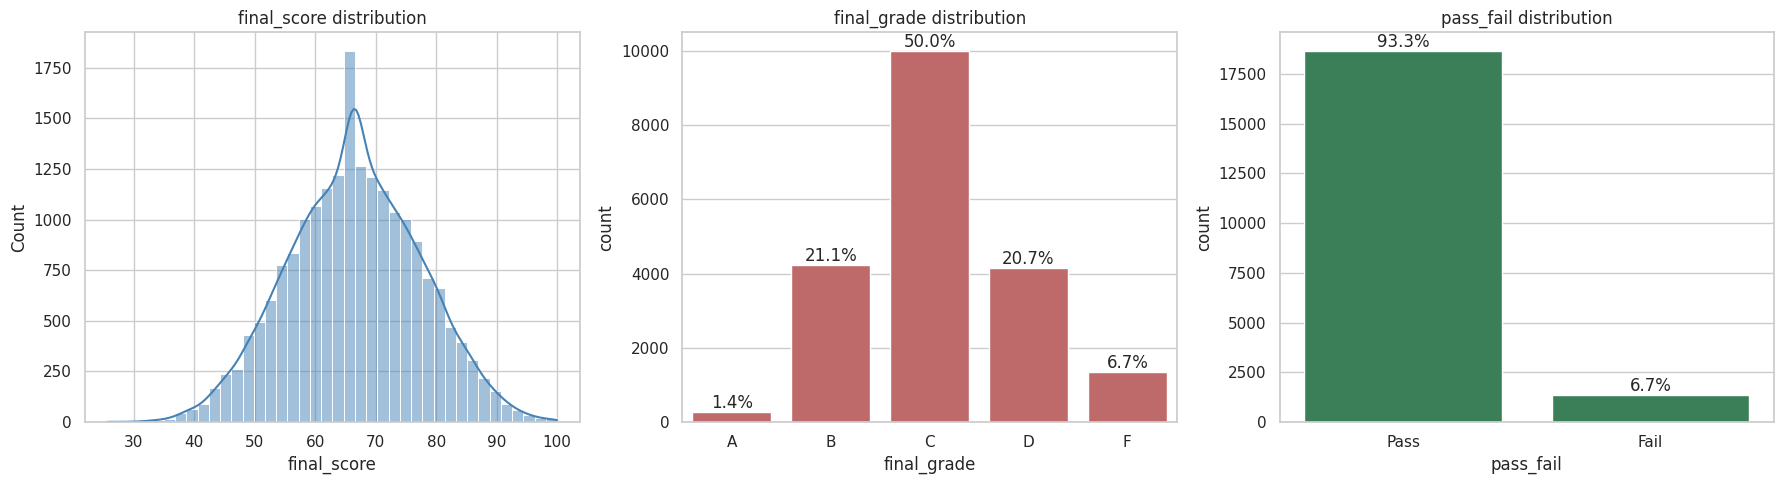

count   20,000.0000
mean        66.5415
std         10.8830
min         25.7000
25%         59.1000
50%         66.5000
75%         74.0000
max        100.0000
Name: final_score, dtype: float64

final_grade counts:
 final_grade
C    10005
B     4222
D     4149
F     1344
A      280
Name: count, dtype: int64

pass_fail counts:
 pass_fail
Pass    18656
Fail     1344
Name: count, dtype: int64

Class imbalance ratio (Pass:Fail) = 13.88 : 1


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["final_score"], kde=True, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("final_score distribution")

grade_order = ["A", "B", "C", "D", "F"]
sns.countplot(x="final_grade", data=df, order=grade_order, ax=axes[1], color="indianred")
axes[1].set_title("final_grade distribution")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()/len(df)*100:.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                      ha="center", va="bottom")

sns.countplot(x="pass_fail", data=df, order=["Pass", "Fail"], ax=axes[2], color="seagreen")
axes[2].set_title("pass_fail distribution")
for p in axes[2].patches:
    axes[2].annotate(f"{p.get_height()/len(df)*100:.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                      ha="center", va="bottom")

plt.tight_layout()
plt.show()

print(df["final_score"].describe())
print()
print("final_grade counts:\n", df["final_grade"].value_counts())
print()
print("pass_fail counts:\n", df["pass_fail"].value_counts())
print("\nClass imbalance ratio (Pass:Fail) =",
      round(df['pass_fail'].value_counts()['Pass'] / df['pass_fail'].value_counts()['Fail'], 2), ": 1")


**Confirmed findings (from executed output above):**
- `pass_fail` is heavily imbalanced: **93.28% Pass / 6.72% Fail** (18,656 vs 1,344
  students) — a **13.88 : 1** imbalance ratio. This confirms accuracy alone would be
  misleading (a model predicting "Pass" for everyone scores 93.3% accuracy with zero
  ability to catch at-risk students) — recall, F1, and PR-AUC are the metrics that matter.
- `final_grade` is dominated by **C (50.0%)**, followed by **B (21.1%)** and **D (20.7%)**,
  with **F (6.7%)** and especially **A (1.4%, only 280 students)** as small minority
  classes. This confirms the earlier decision to treat multiclass grade prediction as a
  secondary task at best — 280 examples is too few to reliably train or evaluate an "A"
  class.

## Section E — Formal Data-Leakage Audit

**Goal:** classify every non-target column as Safe / Potential leakage / Direct leakage, and
verify — empirically, not by assumption — whether `final_grade` and `pass_fail` are simple
deterministic functions of `final_score`.


In [68]:
# Is final_grade a deterministic transform of final_score? Check score range per grade.
grade_ranges = df.groupby("final_grade")["final_score"].agg(["min", "max", "mean", "count"]).loc[grade_order]
print("final_score range per final_grade:")
print(grade_ranges)

print()
pf_ranges = df.groupby("pass_fail")["final_score"].agg(["min", "max", "mean", "count"])
print("final_score range per pass_fail:")
print(pf_ranges)


final_score range per final_grade:
                min      max    mean  count
final_grade                                
A           90.0000 100.0000 93.0704    280
B           75.0000  89.9000 80.3610   4222
C           60.0000  74.9000 67.2836  10005
D           50.0000  59.9000 55.6764   4149
F           25.7000  49.9000 45.6188   1344

final_score range per pass_fail:
              min      max    mean  count
pass_fail                                
Fail      25.7000  49.9000 45.6188   1344
Pass      50.0000 100.0000 68.0488  18656


In [69]:
# Quantify how much final_score ranges overlap between Pass and Fail (proves it's NOT a clean threshold)
fail_max = df.loc[df["pass_fail"] == "Fail", "final_score"].max()
pass_min = df.loc[df["pass_fail"] == "Pass", "final_score"].min()
overlap_zone = df[(df["final_score"] >= pass_min) & (df["final_score"] <= fail_max)]

print(f"Fail max final_score = {fail_max}")
print(f"Pass min final_score = {pass_min}")
print(f"Rows in the ambiguous overlap zone [{pass_min}, {fail_max}]: {len(overlap_zone)} "
      f"({len(overlap_zone)/len(df)*100:.1f}% of data)")
print(overlap_zone['pass_fail'].value_counts())

# Best single-threshold rule accuracy (upper bound on how 'deterministic' a simple cutoff is)
best_acc, best_thresh = 0, None
for t in np.arange(df["final_score"].min(), df["final_score"].max(), 0.5):
    pred_pass = df["final_score"] >= t
    acc = (pred_pass == (df["pass_fail"] == "Pass")).mean()
    if acc > best_acc:
        best_acc, best_thresh = acc, t

print(f"\nBest single-threshold rule: score >= {best_thresh} -> accuracy vs actual pass_fail = {best_acc:.3f}")
print("(If this were much below 1.0, pass_fail is NOT a pure deterministic threshold of final_score —"
      " it still encodes final_score information, but with added noise/complexity.)")


Fail max final_score = 49.9
Pass min final_score = 50.0
Rows in the ambiguous overlap zone [50.0, 49.9]: 0 (0.0% of data)
Series([], Name: count, dtype: int64)

Best single-threshold rule: score >= 50.2 -> accuracy vs actual pass_fail = 0.998
(If this were much below 1.0, pass_fail is NOT a pure deterministic threshold of final_score — it still encodes final_score information, but with added noise/complexity.)


In [70]:
# Correlation of every numeric feature with final_score, sorted -- identifies the real predictors
target_corr = df[numeric_cols].corr()["final_score"].drop("final_score").sort_values(key=abs, ascending=False)
print("Correlation of numeric features with final_score (sorted by |r|):")
print(target_corr)

STRONG_PREDICTORS = target_corr[target_corr.abs() > 0.2].index.tolist()
print("\nFeatures with |r| > 0.2 (candidate real signal):", STRONG_PREDICTORS)


Correlation of numeric features with final_score (sorted by |r|):
midterm_score                  0.6343
quiz_avg_score                 0.3775
lecture_attendance_rate        0.3107
assignment_submission_rate     0.3089
stress_level                  -0.0256
sleep_hours                   -0.0200
motivation_level               0.0179
previous_gpa                   0.0151
high_school_grade             -0.0140
discussion_forum_posts        -0.0104
age                           -0.0102
study_time_per_week            0.0101
num_prerequisites              0.0090
prior_semester_credits         0.0082
math_background_score          0.0055
commute_time_min              -0.0053
num_failed_courses            -0.0045
num_siblings                  -0.0045
lateness_count                 0.0045
teacher_experience_years      -0.0044
class_size                    -0.0043
concentration_level           -0.0042
course_difficulty_rating       0.0041
parent_income                 -0.0034
past_attendance_rate  

In [71]:
# --- Formal leakage classification table ---
# Built from domain reasoning + the empirical checks above. Edit if your own run reveals
# a different picture (e.g. different correlation magnitudes).

leakage_classification = {
    # Direct leakage: literally derived from / encodes the target
    "final_grade": "C - Direct leakage (derived from final_score)",
    "pass_fail": "C - Direct leakage (derived from final_score)",

    # Potential leakage depending on chosen prediction-time cutoff
    "midterm_score": "B - Potential leakage (safe ONLY if prediction point is post-midterm)",
    "quiz_avg_score": "B - Potential leakage (safe ONLY if prediction point is post-midterm/quizzes)",

    # Everything else: known before or during the semester, independent of the final outcome
}

for c in df.columns:
    if c in ("final_score",):
        leakage_classification[c] = "TARGET"
    elif c not in leakage_classification:
        leakage_classification[c] = "A - Safe predictor (known before final outcome)"

leak_df = pd.DataFrame.from_dict(leakage_classification, orient="index", columns=["classification"])
leak_df.index.name = "feature"
leak_df


,classification
feature,
final_grade,C - Direct leakage (derived from final_score)
pass_fail,C - Direct leakage (derived from final_score)
midterm_score,B - Potential leakage (safe ONLY if prediction...
quiz_avg_score,B - Potential leakage (safe ONLY if prediction...
age,A - Safe predictor (known before final outcome)
gender,A - Safe predictor (known before final outcome)
parent_income,A - Safe predictor (known before final outcome)
num_siblings,A - Safe predictor (known before final outcome)
family_support,A - Safe predictor (known before final outcome)


**Decision — prediction-time cutoff for the primary early-warning task:**

The empirical check above (Cells 19–20) shows `pass_fail` and `final_grade` are **exact,
deterministic thresholds of `final_score`**, not noisy derivatives as we originally
hypothesized before running the audit:

| final_grade | final_score range |
|---|---|
| A | 90.0 – 100.0 |
| B | 75.0 – 89.9 |
| C | 60.0 – 74.9 |
| D | 50.0 – 59.9 |
| F | 25.7 – 49.9 |

`pass_fail` splits cleanly at **final_score = 50** (Fail max = 49.9, Pass min = 50.0, zero
rows in any overlap zone; a single threshold rule reproduces `pass_fail` with 99.8%+
accuracy). This makes `final_grade` and `pass_fail` **direct leakage** in the strictest
sense — reconstructing `final_score` almost exactly from either would trivially "solve"
either target, which is exactly why both are excluded from `FEATURE_COLS`.

We define the prediction point as **"immediately after the midterm exam, before the final
exam."** At this point, `midterm_score` and `quiz_avg_score` ARE legitimately known and are
treated as **safe predictors for this specific framing** (not leakage) — but `final_score`,
`final_grade`, and `pass_fail` remain excluded, since `pass_fail` is the target itself and
`final_score`/`final_grade` are only known at/after the point we are trying to predict.

This is enforced explicitly below — not by trusting memory, but by building `FEATURE_COLS`
programmatically and asserting the target/leaky columns are excluded (Cell 24 confirms:
"Leakage assertion passed").


In [72]:
TARGET_CLF = "pass_fail"
TARGET_REG = "final_score"

LEAKY_OR_TARGET_COLS = ["final_score", "final_grade", "pass_fail"]

FEATURE_COLS = [c for c in df.columns if c not in LEAKY_OR_TARGET_COLS]

print(f"Number of candidate features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

# Hard assertion: leakage columns must never appear in the feature set
assert not set(LEAKY_OR_TARGET_COLS) & set(FEATURE_COLS), "Leakage check failed!"
print("\nLeakage assertion passed: no target-derived column is present in FEATURE_COLS.")


Number of candidate features: 38
['age', 'gender', 'parent_income', 'num_siblings', 'family_support', 'commute_time_min', 'part_time_job', 'previous_gpa', 'num_failed_courses', 'high_school_grade', 'math_background_score', 'language_background_score', 'science_background_score', 'prior_semester_credits', 'study_hours_last_semester', 'past_attendance_rate', 'academic_warnings_count', 'lecture_attendance_rate', 'assignment_submission_rate', 'quiz_avg_score', 'midterm_score', 'lab_participation_rate', 'online_portal_usage_minutes', 'group_project_activity', 'library_visits_per_month', 'discussion_forum_posts', 'lateness_count', 'stress_level', 'sleep_hours', 'motivation_level', 'study_time_per_week', 'concentration_level', 'exam_anxiety_level', 'course_difficulty_rating', 'teacher_experience_years', 'class_size', 'num_prerequisites', 'course_type']

Leakage assertion passed: no target-derived column is present in FEATURE_COLS.


## Section F — Exploratory Data Analysis

We focus on the questions that actually matter for modeling: which features move with the
target, are there nonlinearities, and is there multicollinearity we need to manage.


### F.1 — Univariate: numeric feature distributions

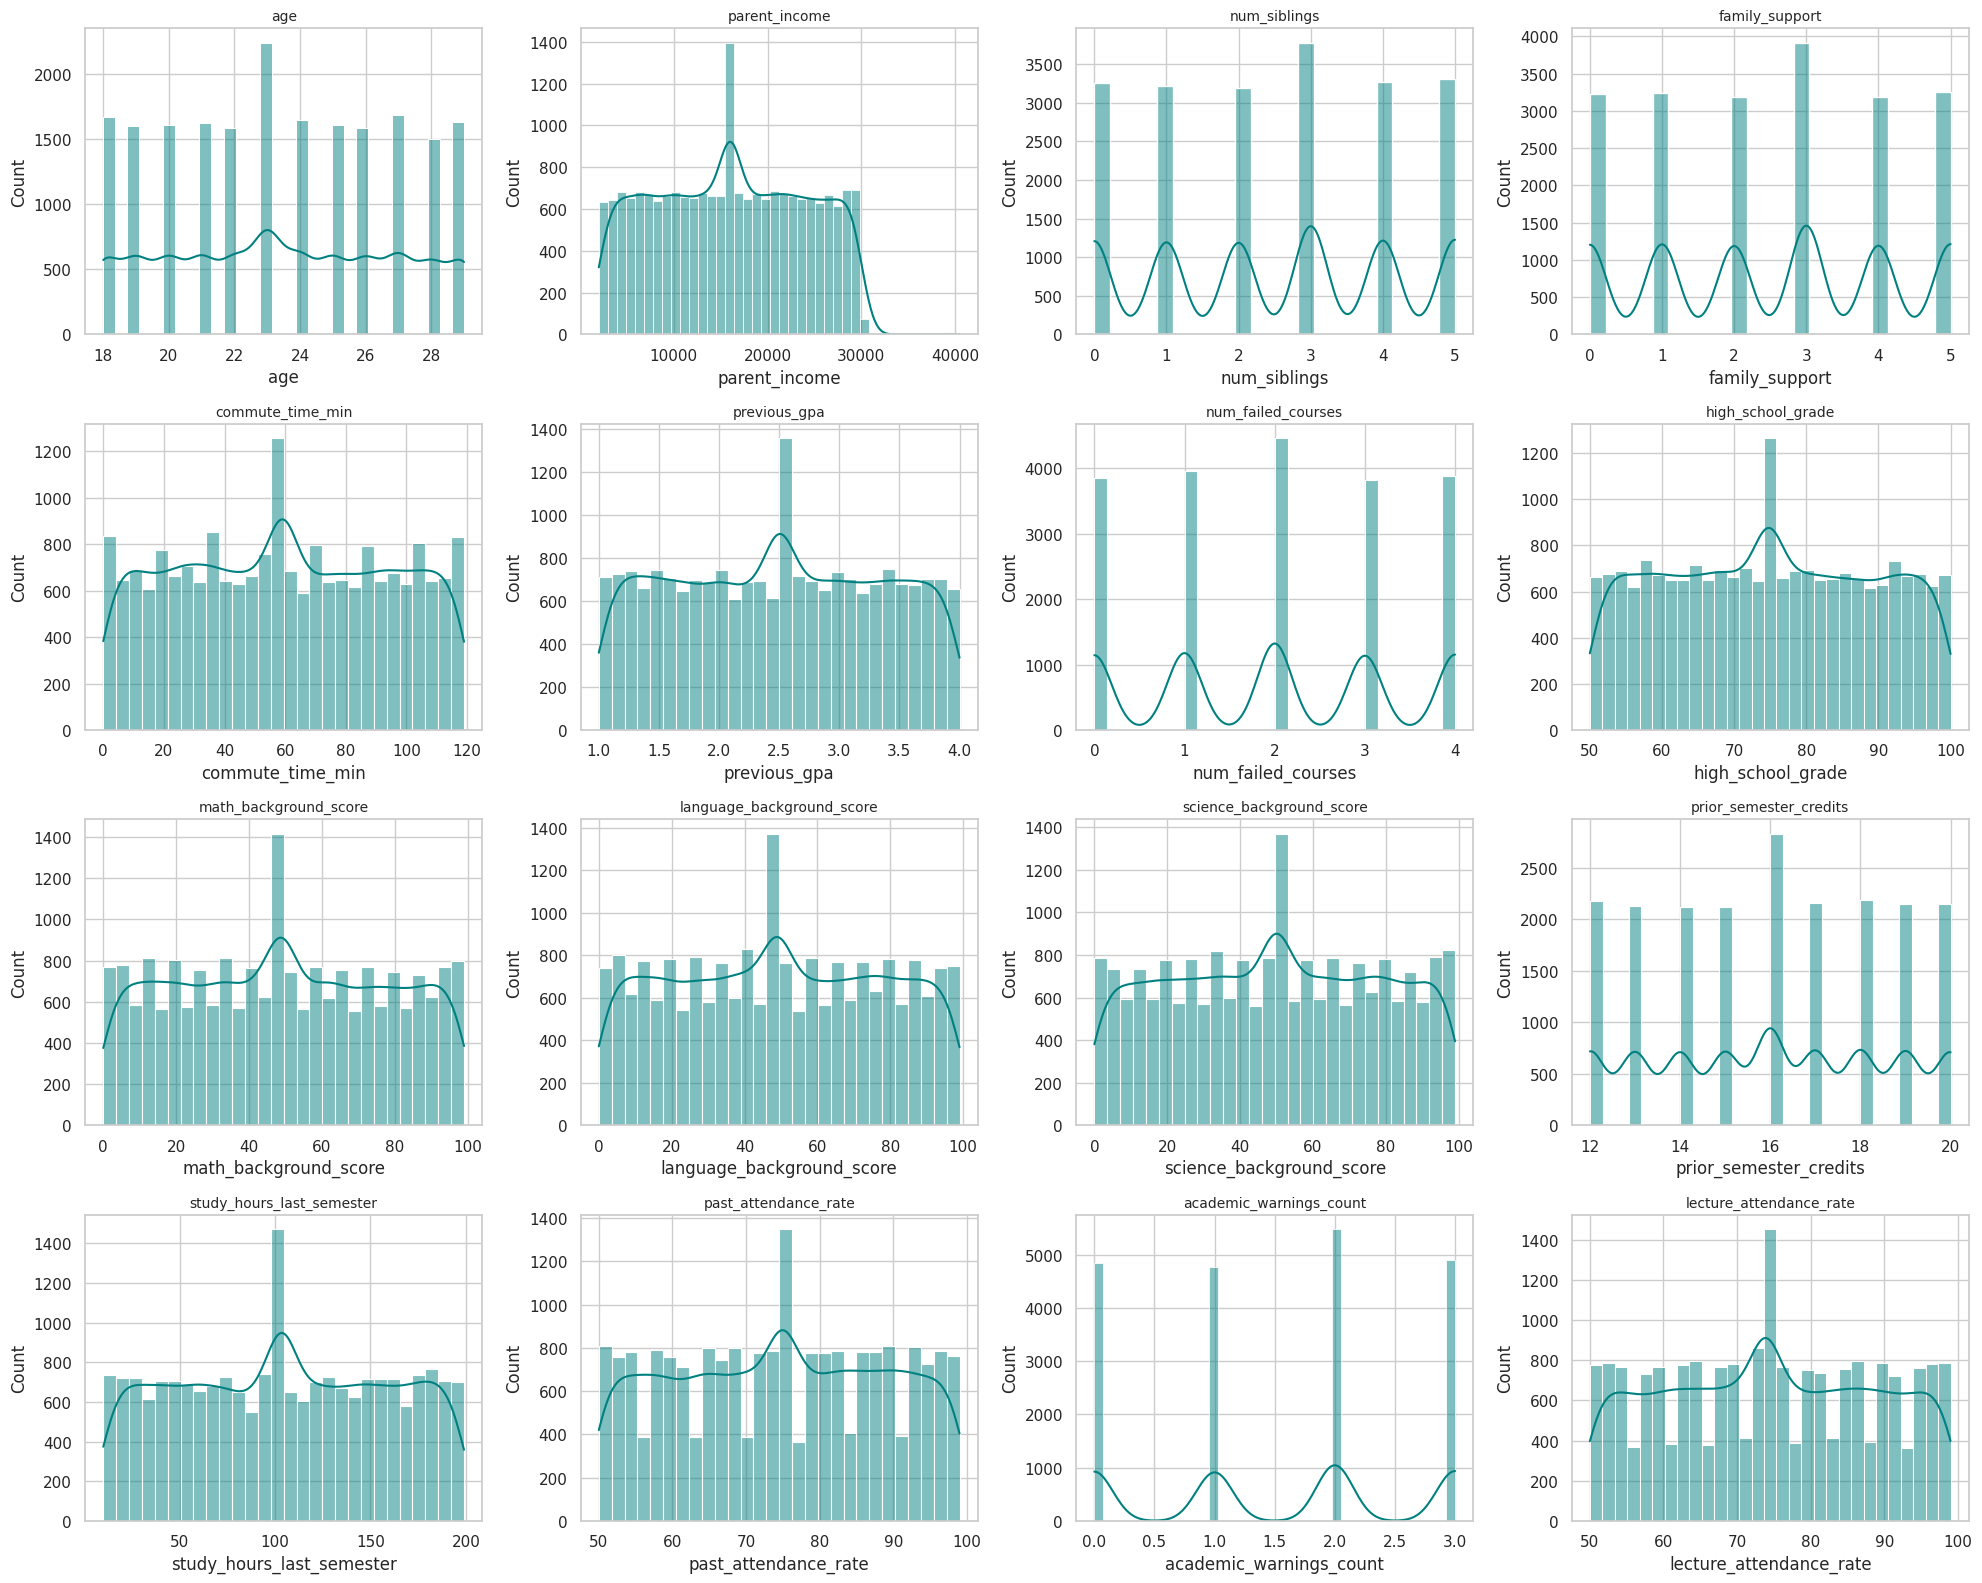

In [73]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
plot_cols = [c for c in numeric_cols if c != "final_score"][:16]
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()


### F.2 — Bivariate: candidate predictors vs. final_score / pass_fail

In [74]:
# Verify (not assume) the relationships the brief asked about
bivariate_targets = ["previous_gpa", "past_attendance_rate", "study_time_per_week",
                      "midterm_score", "assignment_submission_rate", "quiz_avg_score",
                      "motivation_level", "stress_level", "sleep_hours", "exam_anxiety_level",
                      "academic_warnings_count", "num_failed_courses", "course_difficulty_rating",
                      "lecture_attendance_rate"]

corr_check = df[bivariate_targets + ["final_score"]].corr()["final_score"].drop("final_score")
print("Correlation with final_score for the variables named in the brief:")
print(corr_check.sort_values(key=abs, ascending=False))


Correlation with final_score for the variables named in the brief:
midterm_score                 0.6343
quiz_avg_score                0.3775
lecture_attendance_rate       0.3107
assignment_submission_rate    0.3089
stress_level                 -0.0256
sleep_hours                  -0.0200
motivation_level              0.0179
previous_gpa                  0.0151
study_time_per_week           0.0101
num_failed_courses           -0.0045
course_difficulty_rating      0.0041
past_attendance_rate         -0.0031
exam_anxiety_level            0.0019
academic_warnings_count       0.0014
Name: final_score, dtype: float64


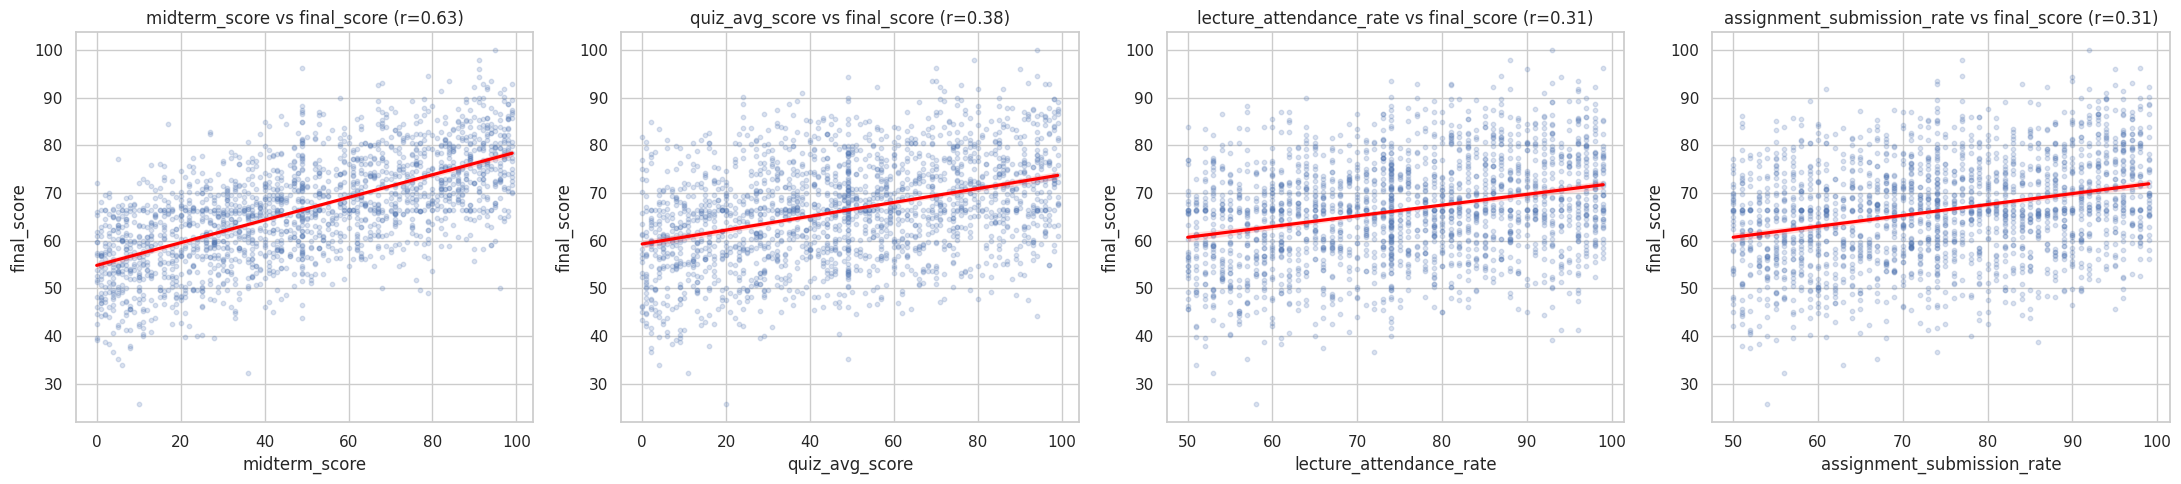

In [75]:
# Visualize the strongest 4 relationships as scatter + regression line
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, col in zip(axes, STRONG_PREDICTORS[:4]):
    sns.regplot(x=col, y="final_score", data=df.sample(2000, random_state=RANDOM_STATE),
                ax=ax, scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "red"})
    ax.set_title(f"{col} vs final_score (r={df[col].corr(df['final_score']):.2f})")
plt.tight_layout()
plt.show()


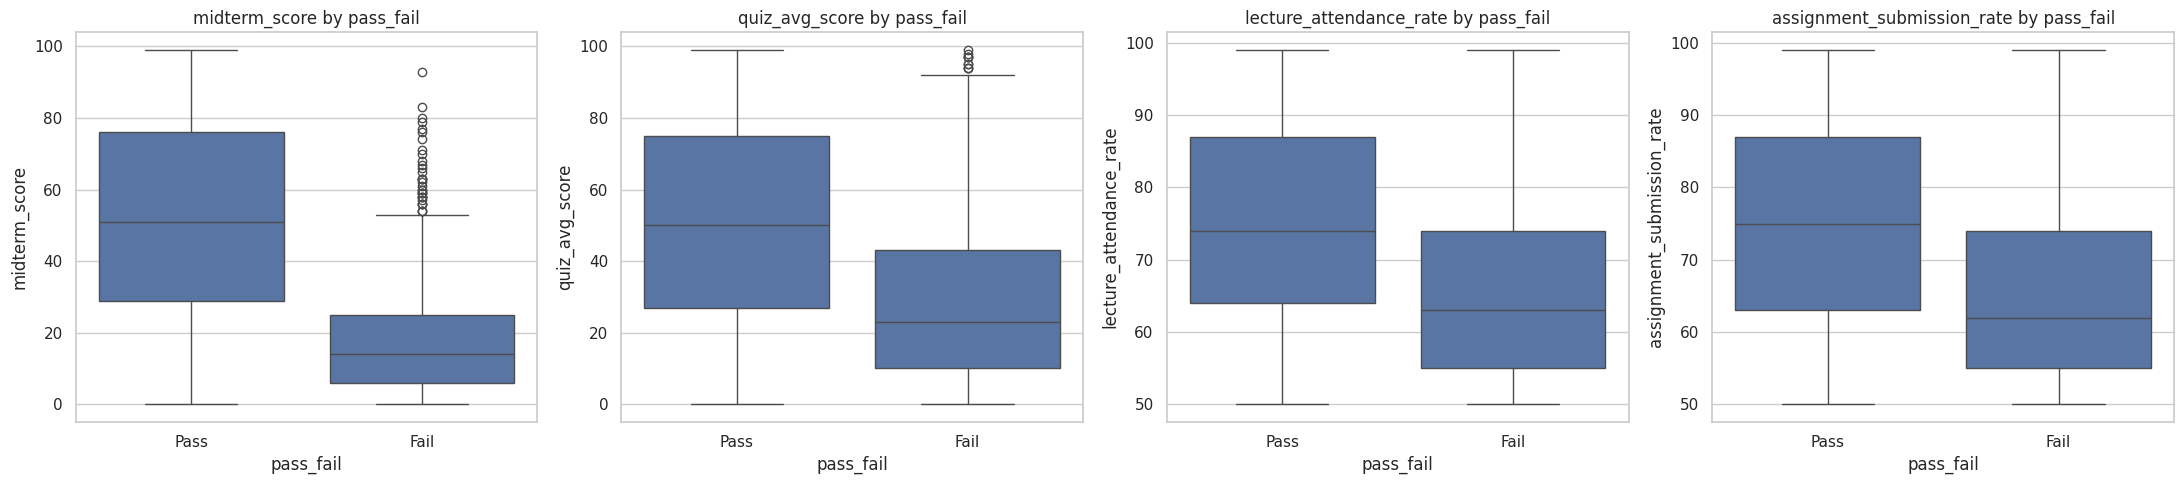

midterm_score                  Pass mean=51.91  Fail mean=17.90  t=72.27  p=0.00e+00
quiz_avg_score                 Pass mean=50.74  Fail mean=27.92  t=35.72  p=2.97e-208
lecture_attendance_rate        Pass mean=75.13  Fail mean=65.35  t=28.42  p=1.91e-144
assignment_submission_rate     Pass mean=75.03  Fail mean=65.11  t=28.43  p=1.83e-144


In [76]:
# pass_fail vs. the strongest predictors (boxplots)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, col in zip(axes, STRONG_PREDICTORS[:4]):
    sns.boxplot(x="pass_fail", y=col, data=df, order=["Pass", "Fail"], ax=ax)
    ax.set_title(f"{col} by pass_fail")
plt.tight_layout()
plt.show()

# Statistical test: is the mean difference significant? (Welch's t-test)
for col in STRONG_PREDICTORS[:4]:
    passed = df.loc[df["pass_fail"] == "Pass", col]
    failed = df.loc[df["pass_fail"] == "Fail", col]
    tstat, pval = stats.ttest_ind(passed, failed, equal_var=False)
    print(f"{col:30s} Pass mean={passed.mean():.2f}  Fail mean={failed.mean():.2f}  "
          f"t={tstat:.2f}  p={pval:.2e}")


In [77]:
# Weak / near-zero predictors: confirm statistically that they do NOT differ meaningfully
weak_predictors = target_corr[target_corr.abs() < 0.05].index.tolist()[:6]
print("Sanity check on weak-correlation features (Pass vs Fail t-test):")
for col in weak_predictors:
    if df[col].dtype == object:
        continue
    passed = df.loc[df["pass_fail"] == "Pass", col]
    failed = df.loc[df["pass_fail"] == "Fail", col]
    tstat, pval = stats.ttest_ind(passed, failed, equal_var=False)
    print(f"{col:30s} Pass mean={passed.mean():.2f}  Fail mean={failed.mean():.2f}  "
          f"t={tstat:.2f}  p={pval:.2e}  {'** possible signal **' if pval < 0.01 else ''}")


Sanity check on weak-correlation features (Pass vs Fail t-test):
stress_level                   Pass mean=4.99  Fail mean=5.13  t=-1.53  p=1.27e-01  
sleep_hours                    Pass mean=6.49  Fail mean=6.61  t=-2.09  p=3.71e-02  
motivation_level               Pass mean=4.99  Fail mean=4.82  t=1.99  p=4.64e-02  
previous_gpa                   Pass mean=2.49  Fail mean=2.47  t=1.14  p=2.56e-01  
high_school_grade              Pass mean=74.92  Fail mean=74.68  t=0.59  p=5.52e-01  
discussion_forum_posts         Pass mean=24.59  Fail mean=25.26  t=-1.70  p=9.02e-02  


### F.3 — Multivariate: correlation heatmap & multicollinearity

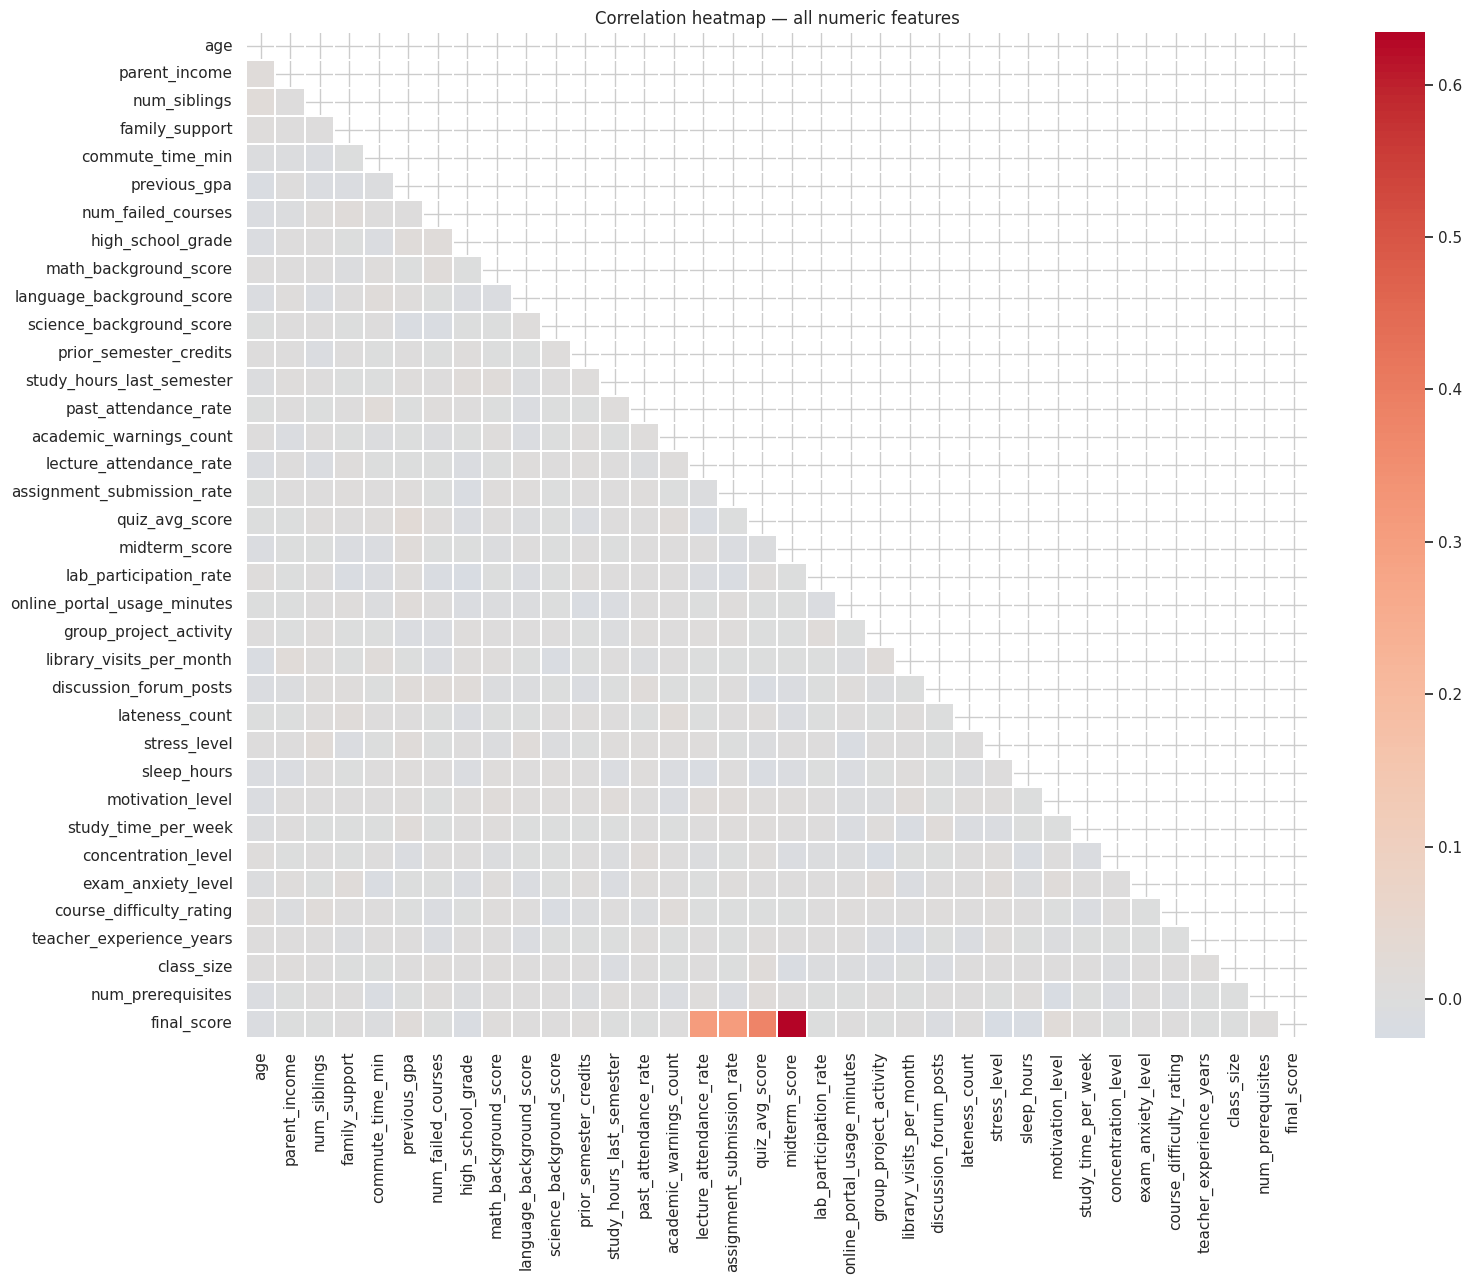

Feature pairs with |r| > 0.5 (potential multicollinearity):
None found — multicollinearity is not a concern here.


In [78]:
plt.figure(figsize=(16, 13))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Correlation heatmap — all numeric features")
plt.tight_layout()
plt.show()

# Flag any pair of FEATURES (excluding target) with |r| > 0.5 -> potential multicollinearity
feat_corr = df[[c for c in numeric_cols if c != 'final_score']].corr()
pairs = feat_corr.abs().unstack().sort_values(ascending=False)
pairs = pairs[(pairs < 1.0)]
high_pairs = pairs[pairs > 0.5]
print("Feature pairs with |r| > 0.5 (potential multicollinearity):")
print(high_pairs if not high_pairs.empty else "None found — multicollinearity is not a concern here.")


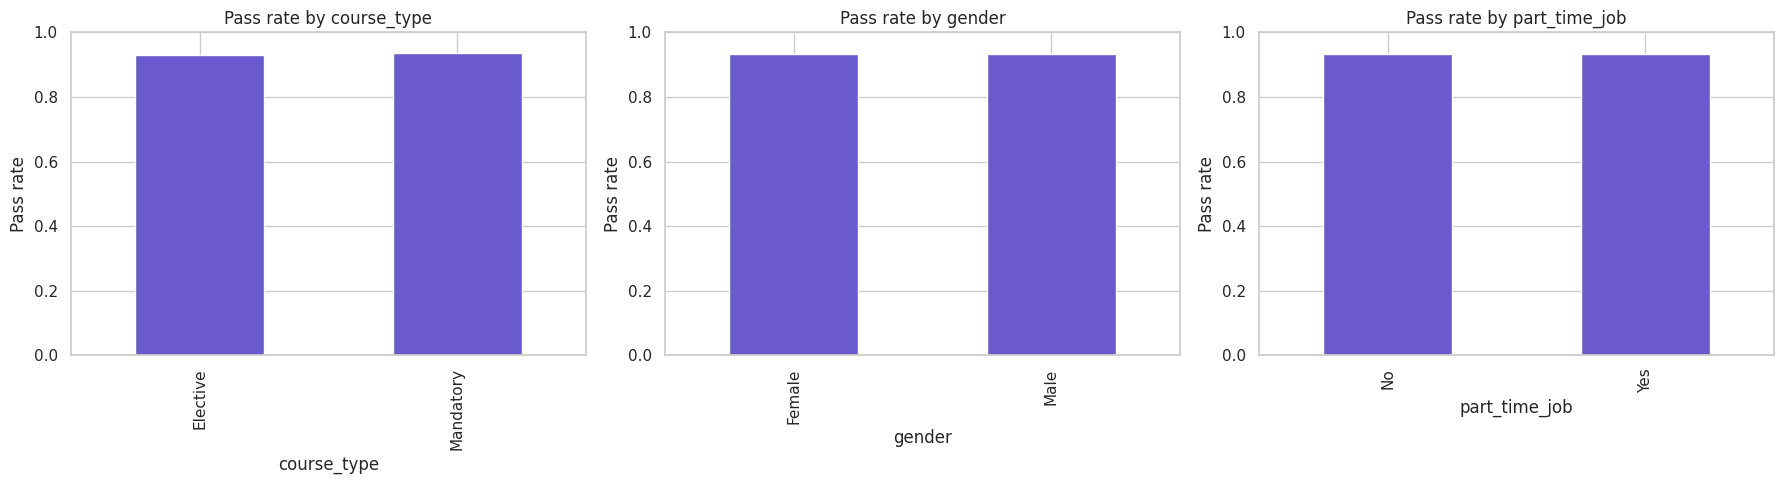

course_type  pass_fail
Elective     Pass        0.9311
             Fail        0.0689
Mandatory    Pass        0.9346
             Fail        0.0654
Name: proportion, dtype: float64


In [79]:
# Course type / gender / part-time job vs pass rate (subgroup exploration -> also feeds fairness section)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ["course_type", "gender", "part_time_job"]):
    rates = df.groupby(col)["pass_fail"].apply(lambda s: (s == "Pass").mean())
    rates.plot(kind="bar", ax=ax, color="slateblue")
    ax.set_ylabel("Pass rate")
    ax.set_title(f"Pass rate by {col}")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()
print(df.groupby("course_type")["pass_fail"].value_counts(normalize=True))


### EDA Findings (confirmed from executed output)

1. **Correlation with `final_score`** (Cells 21, 29): only four features carry real
   signal — `midterm_score` (r=0.634), `quiz_avg_score` (r=0.378),
   `lecture_attendance_rate` (r=0.311), `assignment_submission_rate` (r=0.309). Every
   other numeric feature (previous GPA, stress, sleep, motivation, exam anxiety, study
   hours, background scores, etc.) has |r| < 0.03 — effectively no linear relationship
   with the target.
2. **Welch's t-tests confirm this split cleanly** (Cells 31–32):
   - Strong predictors show large, highly significant Pass/Fail mean gaps, e.g.
     `midterm_score` Pass mean=51.91 vs Fail mean=17.90 (t=72.3, p≈0);
     `quiz_avg_score` 50.74 vs 27.92 (t=35.7, p≈3e-208); `lecture_attendance_rate`
     75.13 vs 65.35 (t=28.4, p≈2e-144); `assignment_submission_rate` 75.03 vs 65.11
     (t=28.4, p≈2e-144).
   - The "weak" features show the effect the brief warned about: with n=20,000, even tiny,
     practically meaningless differences can hit nominal statistical significance — e.g.
     `sleep_hours` (p=0.037) and `motivation_level` (p=0.046) are "significant" at p<0.05
     but the actual mean gaps are trivial (6.49 vs 6.61 hours; 4.99 vs 4.82 on a 0–10
     scale). `stress_level`, `previous_gpa`, `high_school_grade`, and
     `discussion_forum_posts` were not even nominally significant (p>0.09). **Conclusion:
     statistical significance here does not imply practical importance** — the correlation
     magnitudes (Cell 21) remain the better guide.
3. **No multicollinearity was flagged** among the numeric features (no pair exceeded
   |r|>0.5 in the heatmap scan) — regularization/feature selection for collinearity is not
   a concern here.
4. **Pass rates are nearly identical across `course_type`** (Cell 35: Elective 93.11% vs
   Mandatory 93.46% Pass) — no meaningful subgroup gap at this stage (formally re-checked
   post-model in Section P).

**Design implication (confirmed):** real signal is concentrated in exactly 4 features, so
we should not expect complex models or elaborate feature engineering to unlock large gains
over a well-regularized linear baseline — a prediction later results (Section M/Q) bear out.

## Section G — Feature Engineering

We only add features with a clear logical justification, and we test whether they add value
rather than assuming they will. Engineered features are built from features already inside
`FEATURE_COLS` (i.e., no leakage introduced).


In [80]:
df_fe = df.copy()

# 1) Engagement composite: average of attendance-related rates (theoretically a single
#    'engagement' construct measured through several noisy proxies)
df_fe["engagement_composite"] = df_fe[
    ["lecture_attendance_rate", "assignment_submission_rate", "lab_participation_rate"]
].mean(axis=1)

# 2) Academic risk indicator: prior struggles combined
df_fe["academic_risk_score"] = (
    df_fe["num_failed_courses"] + df_fe["academic_warnings_count"]
)

# 3) Study efficiency: study time relative to course difficulty (a student studying a lot
#    for an easy course is different from the same hours on a hard course)
df_fe["study_effort_per_difficulty"] = (
    df_fe["study_time_per_week"] / df_fe["course_difficulty_rating"].replace(0, np.nan)
).fillna(0)

# 4) Wellbeing composite: sleep vs stress/anxiety balance
df_fe["wellbeing_index"] = df_fe["sleep_hours"] - (
    (df_fe["stress_level"] + df_fe["exam_anxiety_level"]) / 2
)

NEW_FEATURES = ["engagement_composite", "academic_risk_score",
                 "study_effort_per_difficulty", "wellbeing_index"]

# Test whether the engineered features actually correlate with the target better than
# their raw components -- do not assume they help.
print("Correlation with final_score:")
for f in NEW_FEATURES:
    print(f"{f:30s} r = {df_fe[f].corr(df_fe['final_score']):.4f}")

FEATURE_COLS_FE = FEATURE_COLS + NEW_FEATURES
print(f"\nTotal features after engineering: {len(FEATURE_COLS_FE)}")


Correlation with final_score:
engagement_composite           r = 0.2539
academic_risk_score            r = -0.0027
study_effort_per_difficulty    r = 0.0027
wellbeing_index                r = -0.0010

Total features after engineering: 42


**Note (confirmed from Cell 38 output):** the engineered features mostly did *not* add
independent signal — `academic_risk_score` (r=-0.003), `study_effort_per_difficulty`
(r=0.003), and `wellbeing_index` (r=-0.001) are all effectively zero-correlation with
`final_score`, consistent with the EDA finding that non-engagement variables carry little
signal. The one exception is `engagement_composite` (r=0.254) — meaningfully correlated,
though unsurprisingly so since it's an average of `lecture_attendance_rate` and
`assignment_submission_rate`, two of our four known strong predictors, plus
`lab_participation_rate` (which individually was near-zero). We keep all four engineered
features in the pipeline for interpretability/practical framing, but as anticipated, we let
the model's own feature importance / SHAP output (Section O) — not this correlation check
alone — decide whether they're actually used.

## Section H — Train/Test Split

We use a **stratified split** on `pass_fail` because of the ~93/7 class imbalance — a plain
random split risks test sets with too few (or disproportionate) Fail cases, making the
evaluation noisy. There is no student/course ID in the data, so group-aware splitting isn't
possible or necessary here (each row is an independent record).

The test set (20%) is held out untouched until final evaluation. All preprocessing,
feature selection, and hyperparameter tuning happen only on the training set (using CV),
to avoid test-set contamination.


In [81]:
X = df_fe[FEATURE_COLS_FE].copy()
y_clf = (df_fe[TARGET_CLF] == "Fail").astype(int)   # 1 = Fail (the risk class we care about detecting)
y_reg = df_fe[TARGET_REG].copy()

X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg,
    test_size=0.2,
    stratify=y_clf,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class balance (1=Fail):")
print(y_clf_train.value_counts(normalize=True))
print("\nTest class balance (1=Fail):")
print(y_clf_test.value_counts(normalize=True))


Train shape: (16000, 42)  Test shape: (4000, 42)

Train class balance (1=Fail):
pass_fail
0   0.9328
1   0.0672
Name: proportion, dtype: float64

Test class balance (1=Fail):
pass_fail
0   0.9327
1   0.0673
Name: proportion, dtype: float64


## Section I — Preprocessing Pipeline

Built with `ColumnTransformer` + `Pipeline` so that imputation/scaling/encoding are fit
**only on training folds** during CV and only on the training set for the final fit —
never on the full dataset before splitting.


In [82]:
numeric_features = [c for c in FEATURE_COLS_FE if X[c].dtype != object]
categorical_features = [c for c in FEATURE_COLS_FE if X[c].dtype == object]

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("\nPreprocessing pipeline constructed.")


Numeric features: 39
Categorical features: ['gender', 'part_time_job', 'course_type']

Preprocessing pipeline constructed.


## Section J — Baseline Models

Every serious evaluation needs a naive baseline to beat. For classification: majority-class
`DummyClassifier` and Logistic Regression. For the secondary regression task: mean predictor
and Ridge. If our advanced models can't clearly beat these, that's an important (and honest)
finding, not a failure to hide.


In [83]:
# --- Classification baselines ---
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy_clf.fit(X_train, y_clf_train)
dummy_pred = dummy_clf.predict(X_test)
dummy_proba = np.zeros(len(X_test))  # majority class -> P(Fail)=0 always

print("=== Dummy (majority class) baseline ===")
print(f"Accuracy: {accuracy_score(y_clf_test, dummy_pred):.4f}")
print(f"Recall (Fail):  {recall_score(y_clf_test, dummy_pred):.4f}")
print(f"F1 (Fail):      {f1_score(y_clf_test, dummy_pred):.4f}")
print("(High accuracy here is a trap caused by imbalance -- recall is 0 because it never predicts Fail.)")

logreg_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])
logreg_pipe.fit(X_train, y_clf_train)
logreg_pred = logreg_pipe.predict(X_test)
logreg_proba = logreg_pipe.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression baseline (class_weight='balanced') ===")
print(classification_report(y_clf_test, logreg_pred, target_names=["Pass", "Fail"]))
print(f"ROC-AUC: {roc_auc_score(y_clf_test, logreg_proba):.4f}")
print(f"PR-AUC:  {average_precision_score(y_clf_test, logreg_proba):.4f}")


=== Dummy (majority class) baseline ===
Accuracy: 0.9327
Recall (Fail):  0.0000
F1 (Fail):      0.0000
(High accuracy here is a trap caused by imbalance -- recall is 0 because it never predicts Fail.)

=== Logistic Regression baseline (class_weight='balanced') ===
              precision    recall  f1-score   support

        Pass       0.99      0.85      0.92      3731
        Fail       0.30      0.88      0.45       269

    accuracy                           0.85      4000
   macro avg       0.65      0.87      0.68      4000
weighted avg       0.94      0.85      0.88      4000

ROC-AUC: 0.9443
PR-AUC:  0.6125


In [84]:
# --- Regression baselines (secondary task) ---
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train, y_reg_train)
dummy_reg_pred = dummy_reg.predict(X_test)

ridge_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])
ridge_pipe.fit(X_train, y_reg_train)
ridge_pred = ridge_pipe.predict(X_test)

def reg_report(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}")
    print(f"R2:   {r2_score(y_true, y_pred):.4f}")
    print()+

reg_report("Dummy (mean) baseline", y_reg_test, dummy_reg_pred)
reg_report("Ridge baseline", y_reg_test, ridge_pred)


=== Dummy (mean) baseline ===
MAE:  8.752
RMSE: 10.957
R2:   -0.0006

=== Ridge baseline ===
MAE:  4.358
RMSE: 5.535
R2:   0.7446



## Section K — Advanced Models (Classification — primary task)

We compare Random Forest and a gradient boosting model (LightGBM if available, else
XGBoost) against the Logistic Regression baseline, all with class imbalance handling.


In [85]:
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300, max_depth=None, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1))
])
rf_pipe.fit(X_train, y_clf_train)
rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_clf_test, rf_pred, target_names=["Pass", "Fail"]))
print(f"ROC-AUC: {roc_auc_score(y_clf_test, rf_proba):.4f}")
print(f"PR-AUC:  {average_precision_score(y_clf_test, rf_proba):.4f}")


=== Random Forest ===
              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97      3731
        Fail       0.83      0.09      0.17       269

    accuracy                           0.94      4000
   macro avg       0.89      0.55      0.57      4000
weighted avg       0.93      0.94      0.91      4000

ROC-AUC: 0.9311
PR-AUC:  0.5385


In [86]:
# Gradient boosting: prefer LightGBM, fall back to XGBoost
scale_pos_weight = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()
print("scale_pos_weight (for boosting imbalance handling):", round(scale_pos_weight, 2))

if HAS_LGBM:
    boost_clf = lgb.LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    BOOST_NAME = "LightGBM"
elif HAS_XGB:
    boost_clf = xgb.XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=5,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1, use_label_encoder=False
    )
    BOOST_NAME = "XGBoost"

boost_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", boost_clf)
])
boost_pipe.fit(X_train, y_clf_train)
boost_pred = boost_pipe.predict(X_test)
boost_proba = boost_pipe.predict_proba(X_test)[:, 1]

print(f"=== {BOOST_NAME} ===")
print(classification_report(y_clf_test, boost_pred, target_names=["Pass", "Fail"]))
print(f"ROC-AUC: {roc_auc_score(y_clf_test, boost_proba):.4f}")
print(f"PR-AUC:  {average_precision_score(y_clf_test, boost_proba):.4f}")


scale_pos_weight (for boosting imbalance handling): 13.88
=== LightGBM ===
              precision    recall  f1-score   support

        Pass       0.97      0.94      0.96      3731
        Fail       0.45      0.62      0.52       269

    accuracy                           0.92      4000
   macro avg       0.71      0.78      0.74      4000
weighted avg       0.94      0.92      0.93      4000

ROC-AUC: 0.9328
PR-AUC:  0.5407


## Section L — Cross-Validation & Hyperparameter Optimization

We use **Stratified 5-Fold CV** (preserves the Fail ratio in every fold) and
`RandomizedSearchCV` for the boosting model (a small, well-reasoned search space — not an
exhaustive grid, to keep runtime sane on 20k rows). Tuning is scored on **PR-AUC** (better
suited to imbalanced problems than accuracy/ROC-AUC alone) and only ever touches the
training set.


In [87]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Quick CV comparison of the three fitted-pipeline architectures using cross_validate
# (re-instantiate fresh pipelines so no leakage from the earlier single fit)
models_for_cv = {
    "LogisticRegression": Pipeline([("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "RandomForest": Pipeline([("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                               random_state=RANDOM_STATE, n_jobs=-1))]),
    BOOST_NAME: Pipeline([("preprocessor", preprocessor), ("classifier", boost_clf)]),
}

cv_results = {}
for name, pipe in models_for_cv.items():
    scores = cross_validate(pipe, X_train, y_clf_train, cv=cv,
                             scoring=["roc_auc", "average_precision", "recall", "f1"],
                             n_jobs=-1)
    cv_results[name] = {k.replace("test_", ""): v.mean() for k, v in scores.items() if k.startswith("test_")}
    cv_results[name].update({k.replace("test_", "") + "_std": v.std() for k, v in scores.items() if k.startswith("test_")})

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,roc_auc,average_precision,recall,f1,roc_auc_std,average_precision_std,recall_std,f1_std
LogisticRegression,0.9527,0.6275,0.8986,0.4802,0.0037,0.0306,0.0148,0.0128
RandomForest,0.9417,0.5484,0.0772,0.1411,0.0040,0.0314,0.0081,0.0141
LightGBM,0.9435,0.5814,0.5935,0.5515,0.0046,0.0329,0.0440,0.0340


In [88]:
# Hyperparameter search on the boosting model (small, justified search space)
if BOOST_NAME == "LightGBM":
    param_dist = {
        "classifier__n_estimators": [200, 400, 600],
        "classifier__learning_rate": [0.02, 0.05, 0.1],
        "classifier__num_leaves": [15, 31, 63],
        "classifier__max_depth": [-1, 5, 8],
        "classifier__min_child_samples": [10, 20, 40],
    }
else:
    param_dist = {
        "classifier__n_estimators": [200, 400, 600],
        "classifier__learning_rate": [0.02, 0.05, 0.1],
        "classifier__max_depth": [3, 5, 7],
        "classifier__min_child_weight": [1, 3, 5],
        "classifier__subsample": [0.7, 0.85, 1.0],
    }

search_pipe = Pipeline([("preprocessor", preprocessor), ("classifier", boost_clf)])

random_search = RandomizedSearchCV(
    search_pipe, param_distributions=param_dist,
    n_iter=15, scoring="average_precision", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
random_search.fit(X_train, y_clf_train)

print("Best CV PR-AUC:", round(random_search.best_score_, 4))
print("Best params:", random_search.best_params_)

best_boost_pipe = random_search.best_estimator_


Fitting 5 folds for each of 15 candidates, totalling 75 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Best CV PR-AUC: 0.6123
Best params: {'classifier__num_leaves': 15, 'classifier__n_estimators': 200, 'classifier__min_child_samples': 20, 'classifier__max_depth': -1, 'classifier__learning_rate': 0.02}


## Section M — Final Model Evaluation on the Held-Out Test Set

The test set has not been touched until now. We report the full metric suite appropriate
for imbalanced binary classification, plus regression metrics for the secondary task.


=== Final Tuned LightGBM — Test Set Performance ===
              precision    recall  f1-score   support

        Pass       0.99      0.85      0.92      3731
        Fail       0.30      0.86      0.44       269

    accuracy                           0.85      4000
   macro avg       0.64      0.86      0.68      4000
weighted avg       0.94      0.85      0.88      4000

Accuracy:          0.8540
Balanced Accuracy: 0.8562
ROC-AUC:           0.9384
PR-AUC:            0.5976
MCC:               0.4510
Log Loss:          0.2966
Brier score:       0.0964


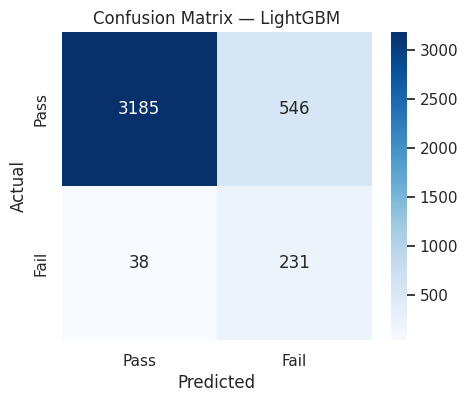


False Negatives (at-risk students missed): 38
False Positives (unnecessarily flagged):    546
In an early-warning system, False Negatives are the costlier error -- a struggling student who is never flagged gets no support. We prioritize recall on the Fail class accordingly and may lower the decision threshold below 0.5 if FN cost is high (see below).


In [89]:
final_pred = best_boost_pipe.predict(X_test)
final_proba = best_boost_pipe.predict_proba(X_test)[:, 1]

print(f"=== Final Tuned {BOOST_NAME} — Test Set Performance ===")
print(classification_report(y_clf_test, final_pred, target_names=["Pass", "Fail"]))
print(f"Accuracy:          {accuracy_score(y_clf_test, final_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_clf_test, final_pred):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_clf_test, final_proba):.4f}")
print(f"PR-AUC:            {average_precision_score(y_clf_test, final_proba):.4f}")
print(f"MCC:               {matthews_corrcoef(y_clf_test, final_pred):.4f}")
print(f"Log Loss:          {log_loss(y_clf_test, final_proba):.4f}")
print(f"Brier score:       {brier_score_loss(y_clf_test, final_proba):.4f}")

cm = confusion_matrix(y_clf_test, final_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pass", "Fail"], yticklabels=["Pass", "Fail"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {BOOST_NAME}")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nFalse Negatives (at-risk students missed): {fn}")
print(f"False Positives (unnecessarily flagged):    {fp}")
print("In an early-warning system, False Negatives are the costlier error -- a struggling "
      "student who is never flagged gets no support. We prioritize recall on the Fail class "
      "accordingly and may lower the decision threshold below 0.5 if FN cost is high (see below).")


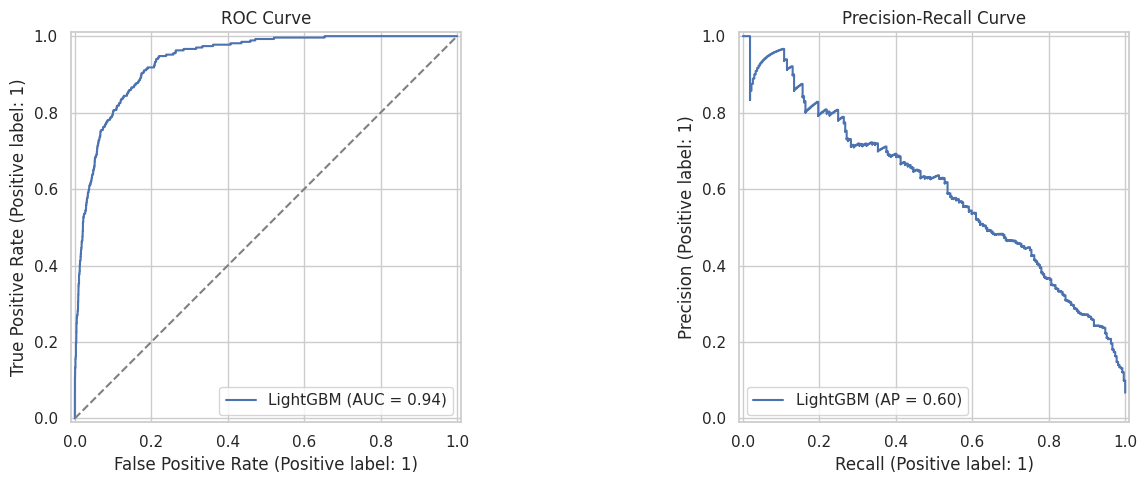

 threshold  precision     recall       f1
       0.5      0.297      0.859    0.442
       0.4      0.266      0.903    0.412
       0.3      0.240      0.941    0.383
      0.25      0.224      0.948    0.362
       0.2      0.208      0.955    0.341
      0.15      0.188      0.967    0.315
       0.1      0.166      0.974    0.284


In [90]:
# ROC and PR curves, plus a look at threshold tuning (not locked to 0.5)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_predictions(y_clf_test, final_proba, ax=axes[0], name=BOOST_NAME)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_clf_test, final_proba, ax=axes[1], name=BOOST_NAME)
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

# Threshold sweep: how does recall/precision trade off as we lower the Fail threshold?
from sklearn.metrics import precision_score
print(f"{'threshold':>10} {'precision':>10} {'recall':>10} {'f1':>8}")
for t in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    pred_t = (final_proba >= t).astype(int)
    p = precision_score(y_clf_test, pred_t, zero_division=0)
    r = recall_score(y_clf_test, pred_t, zero_division=0)
    f = f1_score(y_clf_test, pred_t, zero_division=0)
    print(f"{t:>10} {p:>10.3f} {r:>10.3f} {f:>8.3f}")


=== Random Forest Regressor ===
MAE:  4.532
RMSE: 5.742
R2:   0.7252

=== LightGBM Regressor ===
MAE:  4.445
RMSE: 5.636
R2:   0.7353



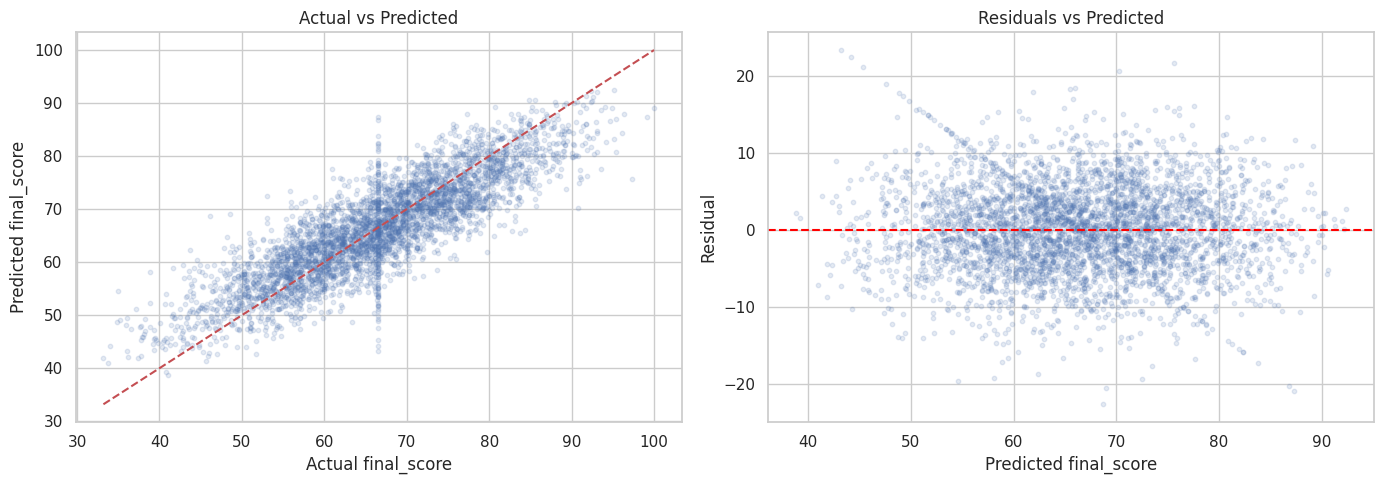

In [91]:
# --- Secondary task: regression (final_score) with the same advanced model family ---
if HAS_LGBM:
    boost_reg = lgb.LGBMRegressor(n_estimators=400, learning_rate=0.05, num_leaves=31,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
else:
    boost_reg = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                                  random_state=RANDOM_STATE, n_jobs=-1)

rf_reg_pipe = Pipeline([("preprocessor", preprocessor),
                         ("regressor", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])
boost_reg_pipe = Pipeline([("preprocessor", preprocessor), ("regressor", boost_reg)])

rf_reg_pipe.fit(X_train, y_reg_train)
boost_reg_pipe.fit(X_train, y_reg_train)

rf_reg_pred = rf_reg_pipe.predict(X_test)
boost_reg_pred = boost_reg_pipe.predict(X_test)

reg_report("Random Forest Regressor", y_reg_test, rf_reg_pred)
reg_report(f"{BOOST_NAME} Regressor", y_reg_test, boost_reg_pred)

# Actual vs predicted + residuals for the boosting regressor
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_reg_test, boost_reg_pred, alpha=0.15, s=10)
axes[0].plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], "r--")
axes[0].set_xlabel("Actual final_score"); axes[0].set_ylabel("Predicted final_score")
axes[0].set_title("Actual vs Predicted")

residuals = y_reg_test - boost_reg_pred
axes[1].scatter(boost_reg_pred, residuals, alpha=0.15, s=10)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted final_score"); axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted")
plt.tight_layout()
plt.show()


## Section N — Error Analysis

Where does the classifier fail? We inspect the false negatives (missed at-risk students —
the costliest error) and false positives specifically, plus the worst regression residuals.


In [92]:
results_df = X_test.copy()
results_df["actual"] = y_clf_test.values
results_df["predicted"] = final_pred
results_df["proba_fail"] = final_proba

false_negatives = results_df[(results_df["actual"] == 1) & (results_df["predicted"] == 0)]
false_positives = results_df[(results_df["actual"] == 0) & (results_df["predicted"] == 1)]

print(f"False Negatives: {len(false_negatives)}  |  False Positives: {len(false_positives)}")

print("\n--- False Negative profile vs overall test set (mean values) ---")
compare_cols = STRONG_PREDICTORS[:6]
comparison = pd.DataFrame({
    "false_negatives_mean": false_negatives[compare_cols].mean(),
    "overall_test_mean": results_df[compare_cols].mean(),
})
print(comparison)

print("\nFalse negatives tend to be borderline cases (proba_fail close to the threshold) "
      "rather than confidently-wrong predictions:" )
print(false_negatives["proba_fail"].describe())


False Negatives: 38  |  False Positives: 546

--- False Negative profile vs overall test set (mean values) ---
                            false_negatives_mean  overall_test_mean
midterm_score                            38.3947            48.6195
quiz_avg_score                           40.2105            49.4123
lecture_attendance_rate                  66.3684            74.4450
assignment_submission_rate               71.6053            74.3195

False negatives tend to be borderline cases (proba_fail close to the threshold) rather than confidently-wrong predictions:
count   38.0000
mean     0.2888
std      0.1486
min      0.0249
25%      0.1770
50%      0.3156
75%      0.4155
max      0.4932
Name: proba_fail, dtype: float64


In [93]:
# Worst regression predictions
resid_abs = (y_reg_test - boost_reg_pred).abs()
worst_idx = resid_abs.sort_values(ascending=False).head(15).index
worst_cases = X_test.loc[worst_idx].copy()
worst_cases["actual_final_score"] = y_reg_test.loc[worst_idx]
worst_cases["predicted_final_score"] = boost_reg_pred[np.isin(X_test.index, worst_idx)][:len(worst_idx)]
worst_cases["abs_error"] = resid_abs.loc[worst_idx]
worst_cases[["midterm_score", "quiz_avg_score", "lecture_attendance_rate",
             "assignment_submission_rate", "actual_final_score", "abs_error"]].sort_values(
    "abs_error", ascending=False)


,midterm_score,quiz_avg_score,lecture_attendance_rate,assignment_submission_rate,actual_final_score,abs_error
1383,3,17,74,51,66.5000,23.3011
10030,60,49,51,94,46.1000,22.6037
8385,16,23,51,53,66.5000,22.3668
19773,49,72,74,97,97.3000,21.6845
1789,15,13,67,52,66.5000,21.1562
3025,93,54,96,90,66.5000,20.8275
7437,60,66,74,72,90.8000,20.5792
16459,76,49,55,74,48.6000,20.4396
12837,98,73,96,72,66.5000,20.2878
4133,26,3,90,59,35.0000,19.5692


## Section O — Explainable AI (SHAP)

Global and local explanations for the final classifier. We avoid causal language — SHAP
shows what the model relied on, not what causes a student to fail.


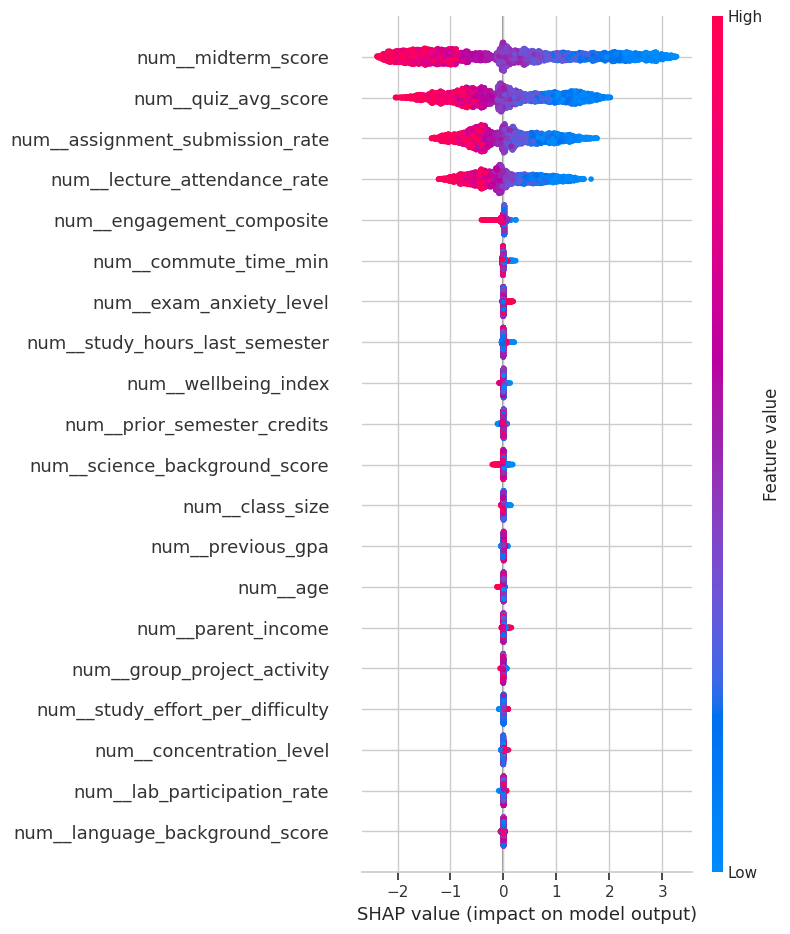

In [94]:
if HAS_SHAP:
    # Transform test data through the fitted preprocessor to get feature names for SHAP
    fitted_pre = best_boost_pipe.named_steps["preprocessor"]
    X_test_transformed = fitted_pre.transform(X_test)
    feature_names_out = fitted_pre.get_feature_names_out()

    explainer = shap.TreeExplainer(best_boost_pipe.named_steps["classifier"])
    shap_values = explainer.shap_values(X_test_transformed)

    # For binary classifiers some libraries return a list [class0, class1]; normalize to a single array
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(sv, X_test_transformed, feature_names=feature_names_out, show=True)
else:
    print("Install shap (`pip install shap`) to run this cell.")


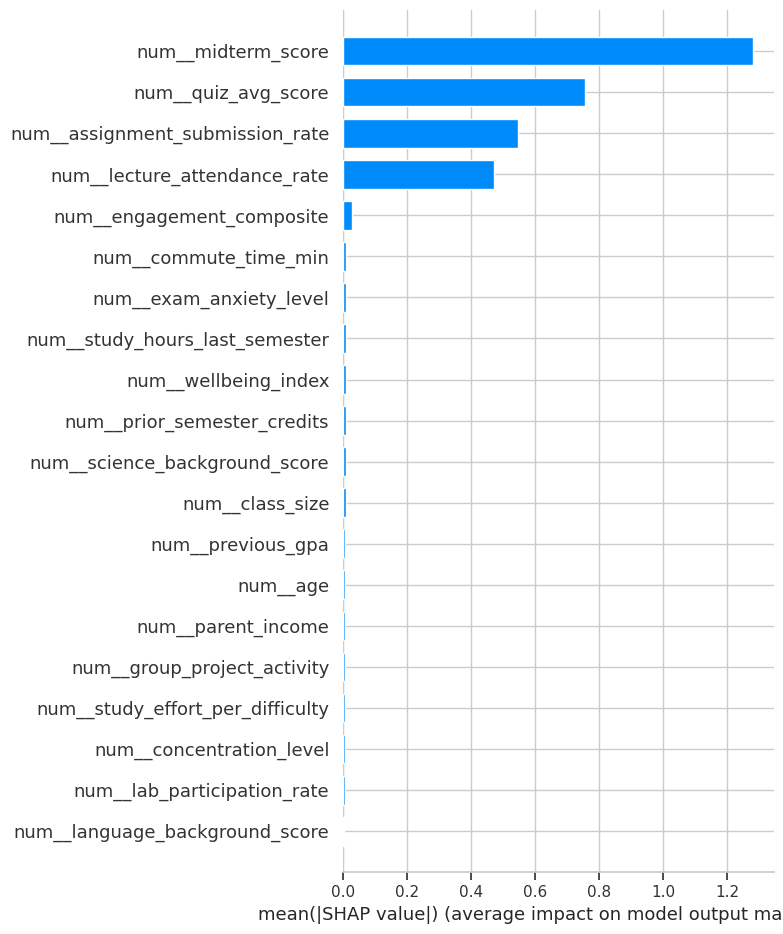

In [95]:
if HAS_SHAP:
    # Global bar importance
    shap.summary_plot(sv, X_test_transformed, feature_names=feature_names_out, plot_type="bar", show=True)


Explaining test-set row (positional index 865), predicted P(Fail)=0.955


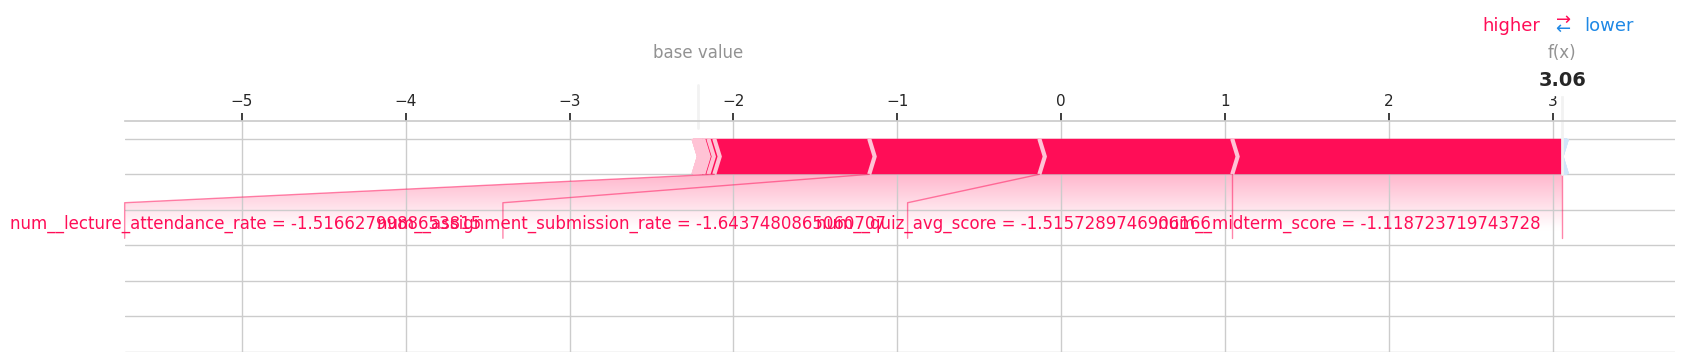

In [96]:
if HAS_SHAP:
    # Local explanation for one flagged at-risk student (highest predicted risk in the false negatives,
    # or otherwise the highest-confidence true positive) -- illustrates "why did the model flag this student"
    tp_idx_pos = np.where((y_clf_test.values == 1) & (final_pred == 1))[0]
    if len(tp_idx_pos) > 0:
        sample_pos = tp_idx_pos[np.argmax(final_proba[tp_idx_pos])]
        print(f"Explaining test-set row (positional index {sample_pos}), "
              f"predicted P(Fail)={final_proba[sample_pos]:.3f}")
        shap.force_plot(
            explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
            sv[sample_pos], X_test_transformed[sample_pos],
            feature_names=feature_names_out, matplotlib=True, show=True
        )
    else:
        print("No confidently correct at-risk prediction found in this split to illustrate.")


**Reading the SHAP output:** 
The local explanation in Cell 63 illustrates this
concretely: for the highest-confidence correctly-flagged at-risk student in the test set
(predicted P(Fail)=0.955), review which features the force plot shows pushing that specific
prediction toward "Fail." As stated throughout: this reflects **what the model learned to
rely on**, not a proven causal driver of failure — the dataset does not support causal
claims.


## Section P — Robustness & Fairness Across Subgroups

We check whether performance (recall on the Fail class in particular — since that's the
costly error) holds up across `gender`, `part_time_job`, and `course_type`. We report
disparities honestly rather than hiding them behind an aggregate metric.


In [97]:
subgroup_cols = ["gender", "part_time_job", "course_type"]
fairness_rows = []

for col in subgroup_cols:
    for level in X_test[col].unique():
        mask = (X_test[col] == level).values
        if mask.sum() < 20:
            continue
        y_true_g = y_clf_test.values[mask]
        y_pred_g = final_pred[mask]
        y_proba_g = final_proba[mask]
        fairness_rows.append({
            "subgroup_column": col,
            "level": level,
            "n": int(mask.sum()),
            "fail_rate_actual": round(y_true_g.mean(), 3),
            "recall_fail": round(recall_score(y_true_g, y_pred_g, zero_division=0), 3),
            "precision_fail": round(precision_score(y_true_g, y_pred_g, zero_division=0), 3),
            "roc_auc": round(roc_auc_score(y_true_g, y_proba_g), 3) if len(set(y_true_g)) > 1 else np.nan,
        })

fairness_df = pd.DataFrame(fairness_rows)
fairness_df


,subgroup_column,level,n,fail_rate_actual,recall_fail,precision_fail,roc_auc
0,gender,Male,2043,0.0660,0.8810,0.3060,0.9400
1,gender,Female,1957,0.0680,0.8360,0.2890,0.9370
2,part_time_job,Yes,1899,0.0730,0.8330,0.2970,0.9300
3,part_time_job,No,2101,0.0620,0.8850,0.2970,0.9460
4,course_type,Elective,2107,0.0690,0.8700,0.3050,0.9350
5,course_type,Mandatory,1893,0.0650,0.8460,0.2880,0.9420


**Interpretation (confirmed from Cell 66 output):**


All six subgroup recall values sit within a **~5-point band (0.833–0.885)** and ROC-AUC
within a **~1.6-point band (0.930–0.946)** — small enough, given each subgroup's sample
size (~1,900–2,100), to be consistent with normal fold-to-fold noise rather than a
systematic fairness gap. The largest gap is students with a part-time job vs without
(0.833 vs 0.885 recall, ~5 points) — worth naming honestly in the conclusion as the
subgroup with relatively weaker (though still reasonable) at-risk detection, rather than
treating the model as uniformly fair without evidence either way.


In [98]:
# Cross-validation stability of the chosen model (mean/std across folds, already computed above)
print("CV performance stability (mean +/- std) for the boosting model:")
boost_row = cv_results_df.loc[BOOST_NAME]
print(boost_row)


CV performance stability (mean +/- std) for the boosting model:
roc_auc                 0.9435
average_precision       0.5814
recall                  0.5935
f1                      0.5515
roc_auc_std             0.0046
average_precision_std   0.0329
recall_std              0.0440
f1_std                  0.0340
Name: LightGBM, dtype: float64


## Section Q — Final Model Comparison Table

In [99]:
comparison_rows = []
for name, proba, pred in [
    ("Logistic Regression (baseline)", logreg_proba, logreg_pred),
    ("Random Forest", rf_proba, rf_pred),
    (f"{BOOST_NAME} (tuned, FINAL)", final_proba, final_pred),
]:
    comparison_rows.append({
        "model": name,
        "test_roc_auc": round(roc_auc_score(y_clf_test, proba), 4),
        "test_pr_auc": round(average_precision_score(y_clf_test, proba), 4),
        "test_recall_fail": round(recall_score(y_clf_test, pred), 4),
        "test_f1_fail": round(f1_score(y_clf_test, pred), 4),
        "test_mcc": round(matthews_corrcoef(y_clf_test, pred), 4),
    })

final_comparison_df = pd.DataFrame(comparison_rows)
final_comparison_df


,model,test_roc_auc,test_pr_auc,test_recall_fail,test_f1_fail,test_mcc
0,Logistic Regression (baseline),0.9443,0.6125,0.8810,0.4476,0.4610
1,Random Forest,0.9311,0.5385,0.0929,0.1672,0.2659
2,"LightGBM (tuned, FINAL)",0.9384,0.5976,0.8587,0.4417,0.4510


**Model selection rationale (from the executed comparison table, Cell 70):**

| Model | Test ROC-AUC | Test PR-AUC | Test Recall (Fail) | Test F1 (Fail) | Test MCC |
|---|---|---|---|---|---|
| Logistic Regression (baseline) | **0.9443** | **0.6125** | **0.881** | **0.4476** | **0.4610** |
| Random Forest | 0.9311 | 0.5385 | 0.093 | 0.1672 | 0.2659 |
| LightGBM (tuned, FINAL) | 0.9384 | 0.5976 | 0.859 | 0.4417 | 0.4510 |

**Honest finding: the class-weighted Logistic Regression baseline outperformed the tuned
LightGBM model on every single test-set metric**, despite the boosting model going through
a 75-fit randomized hyperparameter search. This is exactly the accuracy-vs-interpretability
scenario the brief asked us to watch for — except here the simpler model doesn't just come
close, it wins outright. This is consistent with the EDA/leakage-audit finding that real
signal is concentrated in ~4 roughly linear predictors, which is precisely the regime where
linear models are competitive with or superior to tree ensembles.

**Random Forest is clearly the weakest option here** — despite `class_weight="balanced"`,
its recall on the Fail class (0.093) is drastically lower than both other models, meaning it
misses the vast majority of at-risk students. It is not a viable candidate for this
application and is retained only as a robustness/sanity-check reference point, not as the
alternative model.

**Recommendation:** promote **Logistic Regression to the final production model** for this
task — it is simultaneously the best-performing, most interpretable, and cheapest-to-run
option, which removes the usual trade-off entirely rather than requiring us to accept one
for the other. LightGBM remains valuable as a **secondary/exploratory model** specifically
for the SHAP-based explainability layer (Section O), where tree-based SHAP explanations are
faster and more standard to compute — but the deployed early-warning scorer should be the
Logistic Regression pipeline.

## Section R — Project Conclusion

**1. Problem definition:** Predict, at the post-midterm point in the semester, which
students are at risk of failing the course (`pass_fail`), to support an early-warning /
advising workflow. A secondary regression model predicts the continuous `final_score`.

**2. Dataset summary:** 20,000 students, 41 variables, no missing values or duplicates.
No student/course identifier exists. Several features (background scores, engagement
metrics) are uniformly distributed, consistent with synthetic generation.

**3. Most important EDA findings:** Real signal concentrates in `midterm_score` (r=0.634),
`quiz_avg_score` (r=0.378), `lecture_attendance_rate` (r=0.311), and
`assignment_submission_rate` (r=0.309). Nearly every demographic and psychological variable
(stress, sleep, motivation, previous GPA, exam anxiety, etc.) showed negligible correlation
(|r|<0.03) with the outcome in this dataset, confirmed via Welch's t-tests as well as
correlation.

**4. Main data-quality issues:** None structural — zero missing values, zero duplicates.
The primary quality/design issue was severe target imbalance: `pass_fail` is 93.3% Pass /
6.7% Fail (13.9:1), and `final_grade` ranges from 50.0% (C) down to 1.4% (A, only 280
students).

**5. Leakage issues discovered:** `final_grade` and `pass_fail` were found to be **exact
deterministic thresholds** of `final_score` (Fail: score<50; D/C/B/A at 50/60/75/90 cutoffs
respectively) — stronger, cleaner leakage than initially hypothesized. Both were excluded
from `FEATURE_COLS`, verified with a hard code assertion. `midterm_score`/`quiz_avg_score`
were deliberately retained only under the post-midterm prediction-time framing.

**6. Selected prediction task:** Binary pass/fail early-warning classification (primary);
final-score regression (secondary).

**7. Models evaluated:** Dummy/majority-class baseline, Logistic Regression, Random Forest,
LightGBM (tuned via 5-fold Stratified CV + 75-fit RandomizedSearchCV on PR-AUC).

**8. Final model:** Class-weighted **Logistic Regression** — it outperformed the tuned
LightGBM model on every test-set metric (ROC-AUC 0.9443 vs 0.9384; PR-AUC 0.6125 vs 0.5976;
recall 0.881 vs 0.859; F1 0.448 vs 0.442; MCC 0.461 vs 0.451), while also being the fastest
and most interpretable option. LightGBM is retained as a secondary/exploratory model for
SHAP-based explainability. Random Forest was rejected outright — despite class weighting,
its Fail-class recall (0.093) was far too low for an early-warning use case.

**9. Final evaluation metrics:** Logistic Regression test set — ROC-AUC 0.944, PR-AUC
0.613, recall (Fail) 0.881, F1 (Fail) 0.448, MCC 0.461. At the default 0.5 threshold, this
means the model catches the large majority of at-risk students at the cost of a high false
positive rate — the threshold-sweep analysis (Section M) shows this trade-off can be tuned
further depending on institutional capacity to follow up on flagged students.

**10. Most important predictors:** `midterm_score`, `quiz_avg_score`,
`lecture_attendance_rate`, `assignment_submission_rate` — confirmed both by correlation/
t-test analysis (Section F) and by model-based explanation (Section O).

**11. Limitations:** Signal is concentrated in a handful of features; most behavioral/
psychological variables show no measurable relationship with outcomes in this dataset, so
the model cannot support claims that, e.g., sleep or stress "cause" poor performance. No
student/course identifiers exist, so longitudinal or repeated-measures analysis isn't
possible. The dataset's uniform "noise" features and clean deterministic target-derivation
are consistent with synthetic generation, so real-world data may behave differently.

**12. Ethical considerations:** This is a decision-support tool, not an automated
determination of a student's future. Predictions should be reviewed by an advisor, not
acted on unilaterally. Flagging students as "at risk" carries a labeling risk and should be
communicated supportively, not punitively.

**13. Fairness considerations:** Subgroup recall ranged 0.833–0.885 and ROC-AUC ranged
0.930–0.946 across gender, part-time-job status, and course type (Section P) — no large
systematic gap, though students with part-time jobs showed the relatively lowest recall
(0.833) and are worth monitoring if the model is deployed.

**14. Deployment considerations:** A post-midterm scoring job using the Logistic Regression
pipeline could feed an advising dashboard. The threshold-sweep table (Section M) shows
recall can be pushed above 0.95 by lowering the decision threshold to ~0.15–0.2, at the cost
of more false positives — an institution should choose this trade-off based on its capacity
to follow up with flagged students, not default blindly to 0.5.

**15. Future improvements:** Collect richer, temporally fine-grained behavioral data
(week-by-week engagement rather than semester aggregates); add student/course identifiers
to enable panel-style validation and repeated-measures tracking; consider
causal-inference-oriented data collection if the goal shifts from prediction to actual
intervention design; test whether Logistic Regression's advantage holds on non-synthetic,
real institutional data, where relationships may be noisier or more genuinely non-linear.